In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the original OPSD hourly electricity dataset directly from the public source

data_url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"

raw = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print("Dataset shape:", raw.shape)

raw.head()

Dataset loaded successfully.
Dataset shape: (50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [3]:
# Select German actual load only

germany = raw[["utc_timestamp", "DE_load_actual_entsoe_transparency"]].copy()

germany.columns = ["timestamp", "load"]

germany["timestamp"] = pd.to_datetime(germany["timestamp"])
germany = germany.set_index("timestamp")

germany = germany.loc["2015-01-01":"2020-09-30"]

print(germany.head())
print(germany.tail())
print(germany.isna().sum())

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
timestamp                         
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0
load    0
dtype: int64


In [4]:
# Interpolation included as safety step

germany["load"] = germany["load"].interpolate()

daily_load = germany["load"].resample("D").mean()
weekly_load = germany["load"].resample("W").mean()

print("Hourly rows:", len(germany))
print("Daily rows:", len(daily_load))
print("Weekly rows:", len(weekly_load))

Hourly rows: 50400
Daily rows: 2100
Weekly rows: 301


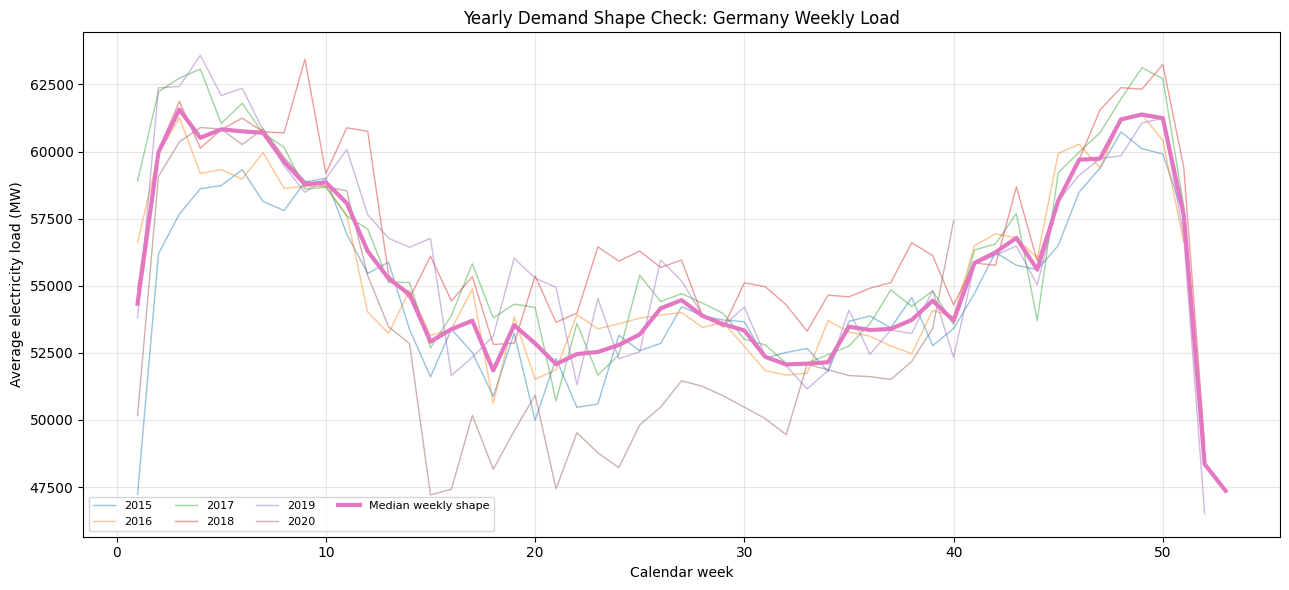

In [5]:
# I used this view to check whether the annual demand shape repeats across years.
# The median line gives a cleaner overall pattern, while the year lines still show variation.

weekly_df = weekly_load.to_frame(name="load")
weekly_df["year"] = weekly_df.index.year
weekly_df["week"] = weekly_df.index.isocalendar().week.astype(int)

weekly_pivot_v2 = weekly_df.pivot_table(
    values="load",
    index="week",
    columns="year",
    aggfunc="mean"
)

plt.figure(figsize=(13, 6))

for yr in weekly_pivot_v2.columns:
    plt.plot(
        weekly_pivot_v2.index,
        weekly_pivot_v2[yr],
        linewidth=1,
        alpha=0.45,
        label=str(yr)
    )

plt.plot(
    weekly_pivot_v2.index,
    weekly_pivot_v2.median(axis=1),
    linewidth=3,
    label="Median weekly shape"
)

plt.title("Yearly Demand Shape Check: Germany Weekly Load")
plt.xlabel("Calendar week")
plt.ylabel("Average electricity load (MW)")
plt.legend(ncol=4, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

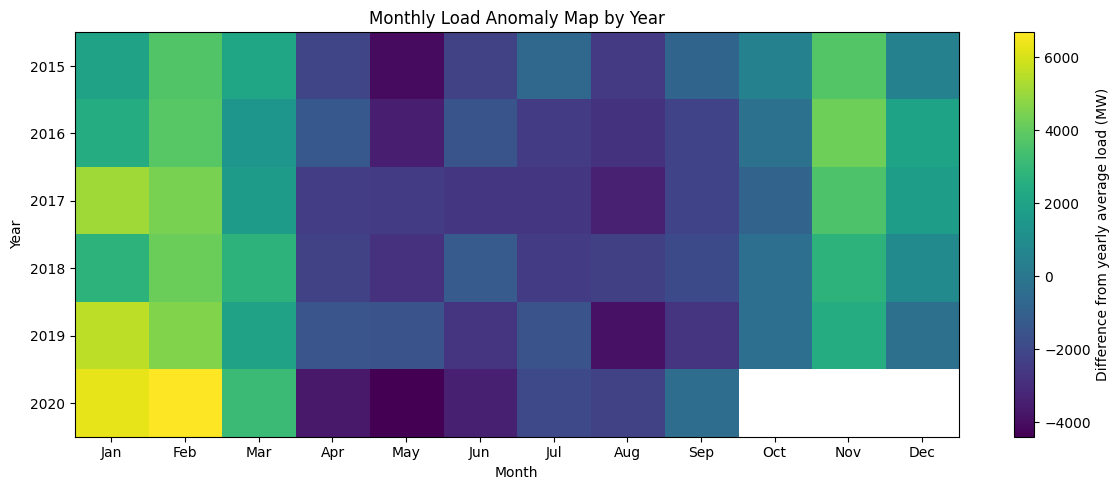

In [6]:
# Instead of only showing raw monthly averages, I show each month's movement around its own year average.
# This makes the warm-month reduction and winter increase easier to see.

monthly_load = germany["load"].resample("M").mean().to_frame(name="load")
monthly_load["year"] = monthly_load.index.year
monthly_load["month"] = monthly_load.index.month

heatmap_data = monthly_load.pivot(index="year", columns="month", values="load")
heatmap_anomaly_v2 = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)

plt.figure(figsize=(12, 5))
plt.imshow(heatmap_anomaly_v2, aspect="auto")
plt.colorbar(label="Difference from yearly average load (MW)")

plt.xticks(
    ticks=np.arange(12),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.yticks(
    ticks=np.arange(len(heatmap_anomaly_v2.index)),
    labels=heatmap_anomaly_v2.index
)

plt.title("Monthly Load Anomaly Map by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

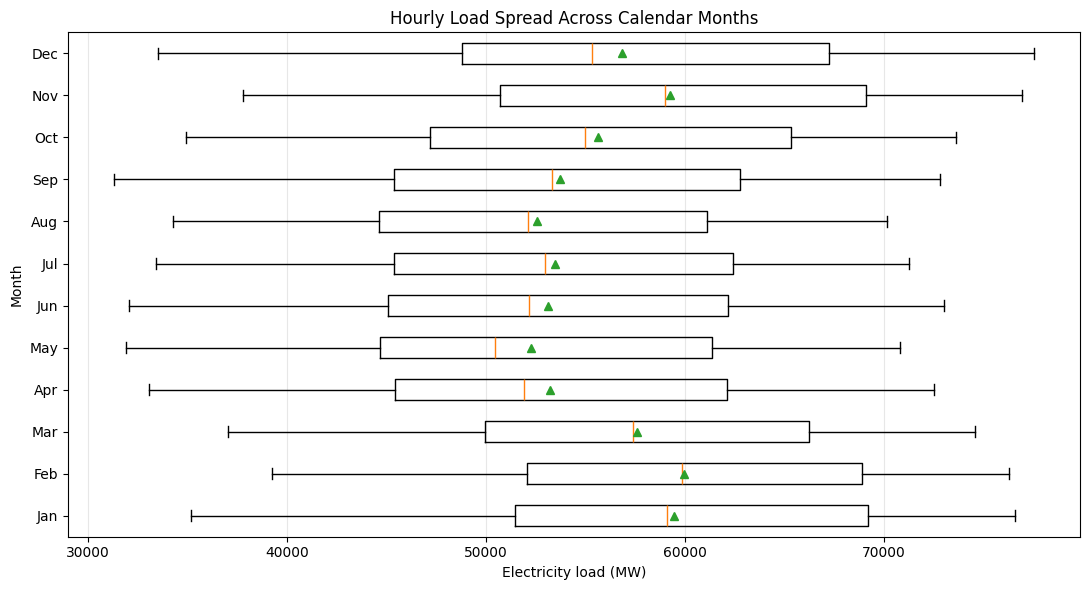

In [7]:
# This boxplot is kept horizontal so the monthly spread is easier to compare in the report.
# It helps show that demand is not only seasonal in the average, but also in its variability.

box_df = germany.copy()
box_df["month"] = box_df.index.month

monthly_values = [
    box_df[box_df["month"] == m]["load"].values
    for m in range(1, 13)
]

month_labels_v2 = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(11, 6))
plt.boxplot(
    monthly_values,
    labels=month_labels_v2,
    vert=False,
    showmeans=True
)

plt.title("Hourly Load Spread Across Calendar Months")
plt.xlabel("Electricity load (MW)")
plt.ylabel("Month")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

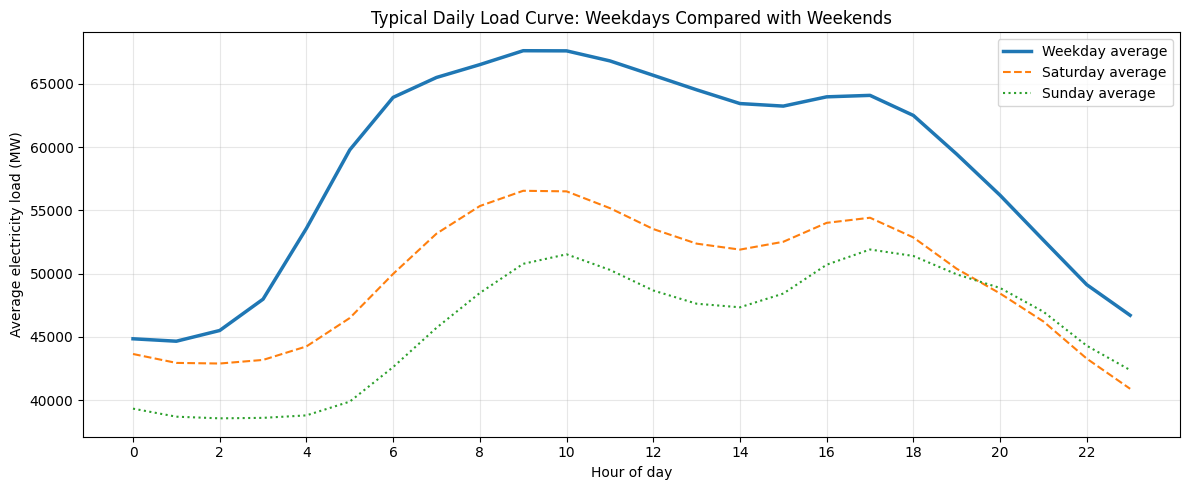

In [8]:
# I separated weekday and weekend profiles because electricity use usually follows a work-pattern rhythm.
# This gives a clearer explanation than only showing a dense hour-by-day heatmap.

profile = germany.copy()
profile["hour"] = profile.index.hour
profile["day_name"] = profile.index.day_name()

weekday_names_v2 = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
weekday_profile_v2 = profile[profile["day_name"].isin(weekday_names_v2)].groupby("hour")["load"].mean()
saturday_profile_v2 = profile[profile["day_name"] == "Saturday"].groupby("hour")["load"].mean()
sunday_profile_v2 = profile[profile["day_name"] == "Sunday"].groupby("hour")["load"].mean()

plt.figure(figsize=(12, 5))
plt.plot(weekday_profile_v2.index, weekday_profile_v2.values, label="Weekday average", linewidth=2.5)
plt.plot(saturday_profile_v2.index, saturday_profile_v2.values, label="Saturday average", linestyle="--")
plt.plot(sunday_profile_v2.index, sunday_profile_v2.values, label="Sunday average", linestyle=":")

plt.title("Typical Daily Load Curve: Weekdays Compared with Weekends")
plt.xlabel("Hour of day")
plt.ylabel("Average electricity load (MW)")
plt.xticks(np.arange(0, 24, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

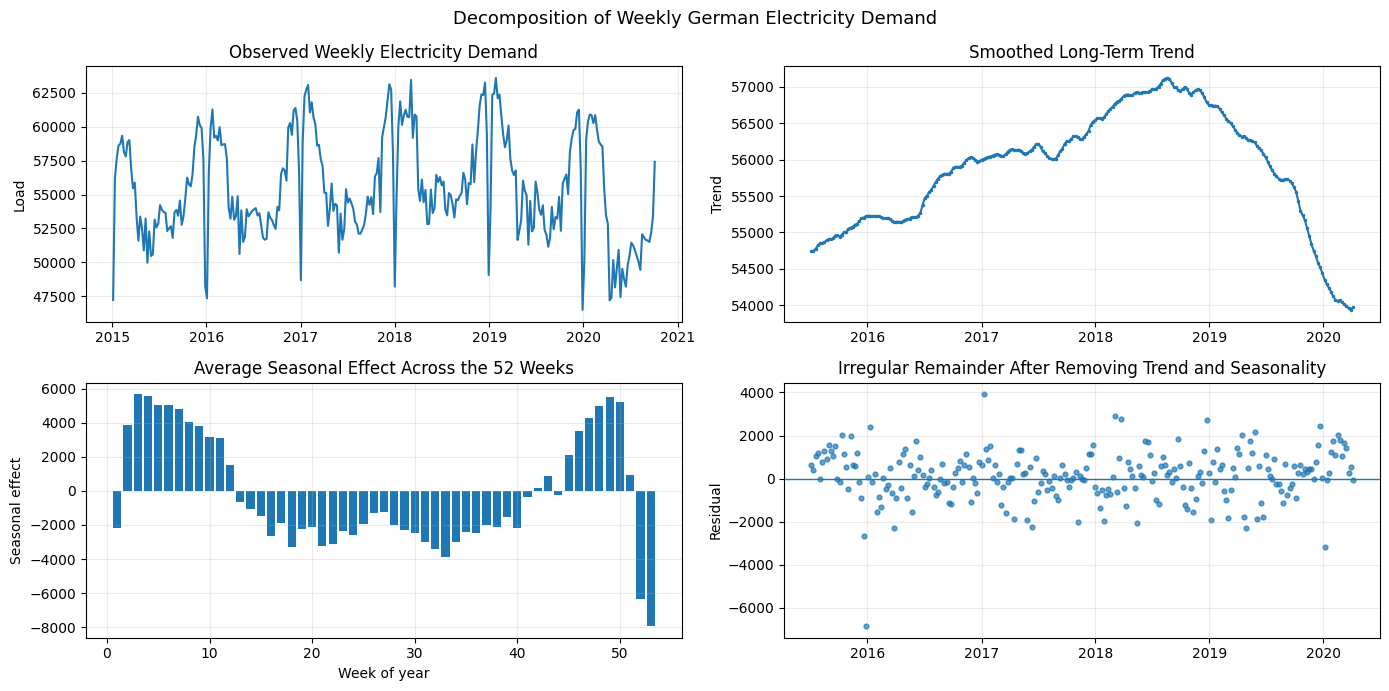

In [9]:
weekly_decomp_v2 = seasonal_decompose(
    weekly_load.dropna(),
    model="additive",
    period=52
)

observed_v2 = weekly_decomp_v2.observed.dropna()
trend_v2 = weekly_decomp_v2.trend.dropna()
seasonal_v2 = weekly_decomp_v2.seasonal.dropna()
residual_v2 = weekly_decomp_v2.resid.dropna()

# Average seasonal effect by week number, so the yearly pattern is clearer
seasonal_by_week_v2 = (
    seasonal_v2
    .groupby(seasonal_v2.index.isocalendar().week)
    .mean()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# 1. Original weekly load as a line
axes[0, 0].plot(observed_v2.index, observed_v2.values)
axes[0, 0].set_title("Observed Weekly Electricity Demand")
axes[0, 0].set_ylabel("Load")

# 2. Trend as a smooth line with points
axes[0, 1].plot(trend_v2.index, trend_v2.values, marker=".", markersize=3)
axes[0, 1].set_title("Smoothed Long-Term Trend")
axes[0, 1].set_ylabel("Trend")

# 3. Seasonal pattern as bars by week of year
axes[1, 0].bar(seasonal_by_week_v2.index.astype(int), seasonal_by_week_v2.values)
axes[1, 0].set_title("Average Seasonal Effect Across the 52 Weeks")
axes[1, 0].set_xlabel("Week of year")
axes[1, 0].set_ylabel("Seasonal effect")

# 4. Residuals as scatter points
axes[1, 1].scatter(residual_v2.index, residual_v2.values, s=12, alpha=0.7)
axes[1, 1].axhline(0, linewidth=1)
axes[1, 1].set_title("Irregular Remainder After Removing Trend and Seasonality")
axes[1, 1].set_ylabel("Residual")

for ax in axes.flatten():
    ax.grid(True, alpha=0.25)

fig.suptitle("Decomposition of Weekly German Electricity Demand", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
def stationarity_summary(series, label):
    series = series.dropna()

    adf_result = adfuller(series)
    kpss_result = kpss(series, regression="c", nlags="auto")

    return {
        "Series": label,
        "ADF Statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS Statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1]
    }

weekly_diff = weekly_load.diff()

stationarity_table = pd.DataFrame([
    stationarity_summary(weekly_load, "Weekly Load"),
    stationarity_summary(weekly_diff, "First Difference")
])

stationarity_table

,Series,ADF Statistic,ADF p-value,KPSS Statistic,KPSS p-value
0,Weekly Load,-4.047472,1.181350e-03,0.160374,0.1
1,First Difference,-7.069318,4.984737e-10,0.055754,0.1


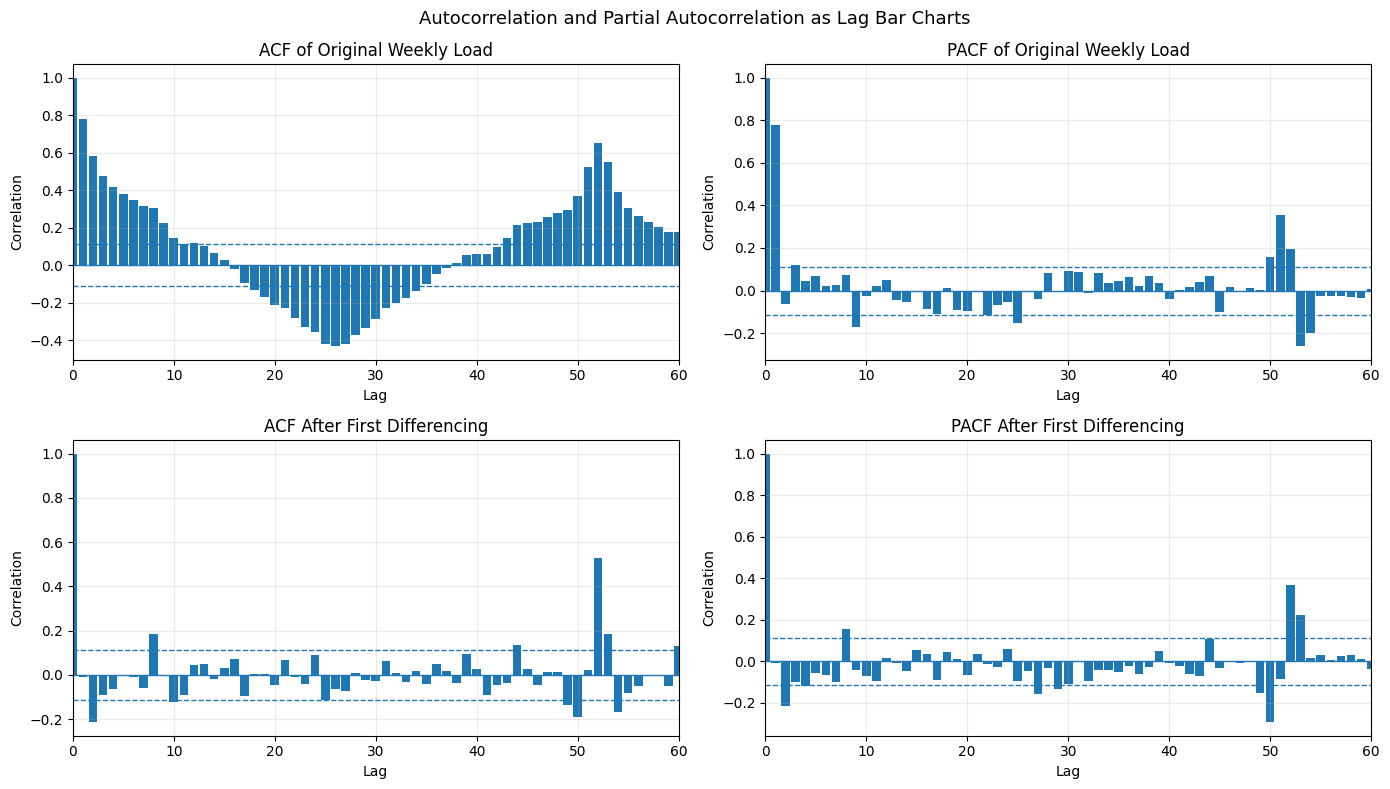

In [11]:
from statsmodels.tsa.stattools import acf, pacf

max_lag_v2 = 60

series_original_v2 = weekly_load.dropna()
series_diff_v2 = weekly_diff.dropna()

acf_original_v2 = acf(series_original_v2, nlags=max_lag_v2, fft=True)
pacf_original_v2 = pacf(series_original_v2, nlags=max_lag_v2, method="ywm")

acf_diff_v2 = acf(series_diff_v2, nlags=max_lag_v2, fft=True)
pacf_diff_v2 = pacf(series_diff_v2, nlags=max_lag_v2, method="ywm")

lags_v2 = np.arange(max_lag_v2 + 1)

conf_original_v2 = 1.96 / np.sqrt(len(series_original_v2))
conf_diff_v2 = 1.96 / np.sqrt(len(series_diff_v2))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

acf_pacf_items_v2 = [
    (acf_original_v2, conf_original_v2, "ACF of Original Weekly Load", axes[0, 0]),
    (pacf_original_v2, conf_original_v2, "PACF of Original Weekly Load", axes[0, 1]),
    (acf_diff_v2, conf_diff_v2, "ACF After First Differencing", axes[1, 0]),
    (pacf_diff_v2, conf_diff_v2, "PACF After First Differencing", axes[1, 1])
]

for values, conf_limit, title, ax in acf_pacf_items_v2:
    ax.bar(lags_v2, values, width=0.85)
    ax.axhline(0, linewidth=1)
    ax.axhline(conf_limit, linestyle="--", linewidth=1)
    ax.axhline(-conf_limit, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")
    ax.set_xlim(0, max_lag_v2)
    ax.grid(True, alpha=0.25)

fig.suptitle("Autocorrelation and Partial Autocorrelation as Lag Bar Charts", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
weekly_demand_v2 = weekly_load.copy()

from sklearn.metrics import mean_squared_error, mean_absolute_error

def score_forecast(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return rmse, mae, mape

In [13]:
# Train-test split
# Last 104 weeks = approximately 2 years for testing

forecast_horizon = 104

train_v2 = weekly_demand_v2.iloc[:-forecast_horizon]
test_v2 = weekly_demand_v2.iloc[-forecast_horizon:]

print("Training period:", train_v2.index.min(), "to", train_v2.index.max())
print("Testing period:", test_v2.index.min(), "to", test_v2.index.max())
print("Train size:", len(train_v2))
print("Test size:", len(test_v2))

Training period: 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing period: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Train size: 197
Test size: 104


In [14]:
# Creating benchmark forecasts

benchmark_forecasts = {}

# 1. Mean forecast
benchmark_forecasts["Mean Forecast"] = pd.Series(
    data=np.repeat(train_v2.mean(), forecast_horizon),
    index=test_v2.index
)

# 2. Naive forecast
benchmark_forecasts["Naive Forecast"] = pd.Series(
    data=np.repeat(train_v2.iloc[-1], forecast_horizon),
    index=test_v2.index
)

# 3. Seasonal naive forecast
# Since data is weekly, 52 weeks represents one yearly season

last_year_values = train_v2.iloc[-52:].values

seasonal_prediction = np.tile(
    last_year_values,
    int(np.ceil(forecast_horizon / 52))
)[:forecast_horizon]

benchmark_forecasts["Seasonal Naive Forecast"] = pd.Series(
    data=seasonal_prediction,
    index=test_v2.index
)

# 4. Drift forecast
first_observation = train_v2.iloc[0]
last_observation = train_v2.iloc[-1]

slope = (last_observation - first_observation) / (len(train_v2) - 1)

drift_prediction = [
    last_observation + slope * step
    for step in range(1, forecast_horizon + 1)
]

benchmark_forecasts["Drift Forecast"] = pd.Series(
    data=drift_prediction,
    index=test_v2.index
)

In [15]:
# Evaluate all benchmark models

benchmark_summary = []

for model_name, prediction in benchmark_forecasts.items():
    rmse, mae, mape = score_forecast(test_v2, prediction)

    benchmark_summary.append({
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

benchmark_results_v2 = pd.DataFrame(benchmark_summary)

benchmark_results_v2 = benchmark_results_v2.sort_values("RMSE").reset_index(drop=True)

benchmark_results_v2

,Model,RMSE,MAE,MAPE
0,Seasonal Naive Forecast,3006.760812,2318.520585,4.408920
1,Mean Forecast,4397.299694,3788.833122,6.969238
2,Naive Forecast,4459.108546,3783.202934,6.790082
3,Drift Forecast,5117.957264,4339.890674,8.049685


In [16]:
# Identify the best benchmark model

best_benchmark_name = benchmark_results_v2.loc[0, "Model"]

print("Best benchmark model:", best_benchmark_name)

Best benchmark model: Seasonal Naive Forecast


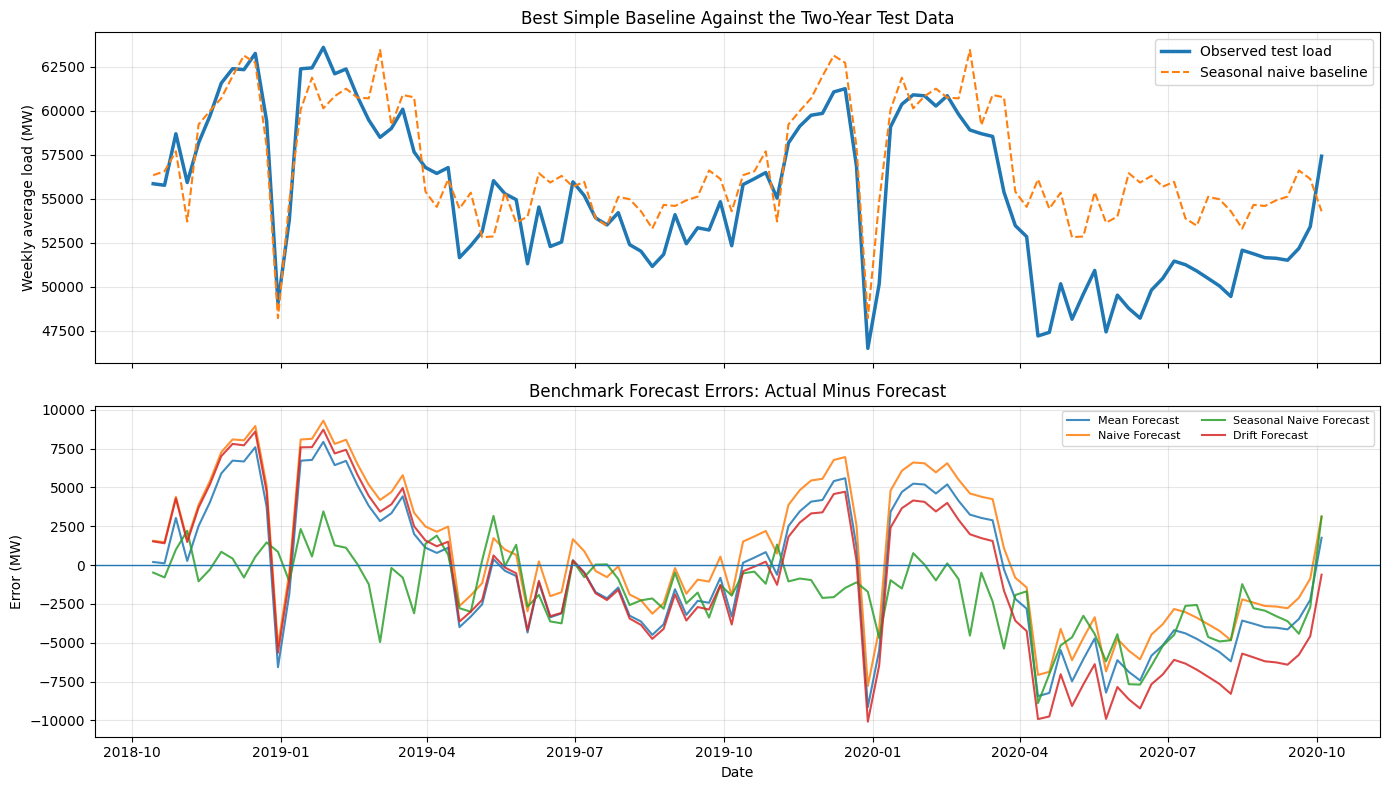

In [17]:
# The first panel compares the main benchmark with the real test values.
# The second panel shows the errors for every simple benchmark, which makes the baseline discussion more honest.

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(test_v2.index, test_v2.values, label="Observed test load", linewidth=2.5)
axes[0].plot(
    benchmark_forecasts["Seasonal Naive Forecast"].index,
    benchmark_forecasts["Seasonal Naive Forecast"].values,
    label="Seasonal naive baseline",
    linestyle="--"
)
axes[0].set_title("Best Simple Baseline Against the Two-Year Test Data")
axes[0].set_ylabel("Weekly average load (MW)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, forecast in benchmark_forecasts.items():
    axes[1].plot(
        forecast.index,
        test_v2 - forecast,
        label=name,
        alpha=0.85
    )

axes[1].axhline(0, linewidth=1)
axes[1].set_title("Benchmark Forecast Errors: Actual Minus Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Error (MW)")
axes[1].legend(ncol=2, fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

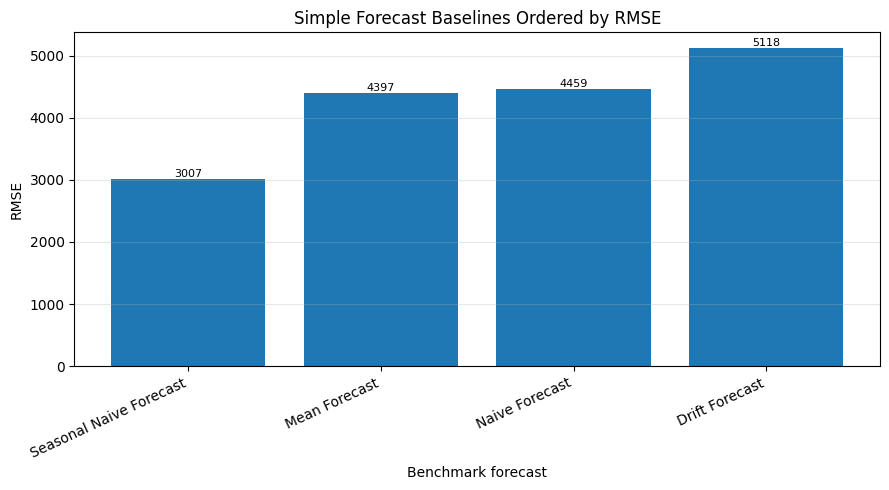

In [18]:
# Ranking the benchmark errors makes it clear why seasonal naive becomes the main comparison point.

ordered_benchmarks_v2 = benchmark_results_v2.sort_values("RMSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.bar(
    ordered_benchmarks_v2["Model"],
    ordered_benchmarks_v2["RMSE"]
)

for idx, value in enumerate(ordered_benchmarks_v2["RMSE"]):
    plt.text(idx, value, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

plt.title("Simple Forecast Baselines Ordered by RMSE")
plt.xlabel("Benchmark forecast")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Store best benchmark
best_benchmark_v2 = benchmark_results_v2.iloc[0]

print("Best benchmark:")
print(best_benchmark_v2)

Best benchmark:
Model    Seasonal Naive Forecast
RMSE                 3006.760812
MAE                  2318.520585
MAPE                     4.40892
Name: 0, dtype: object


In [20]:
print("Train length:", len(train_v2))
print("Test length:", len(test_v2))
print("Train start:", train_v2.index.min())
print("Train end:", train_v2.index.max())
print("Test start:", test_v2.index.min())
print("Test end:", test_v2.index.max())

Train length: 197
Test length: 104
Train start: 2015-01-04 00:00:00+00:00
Train end: 2018-10-07 00:00:00+00:00
Test start: 2018-10-14 00:00:00+00:00
Test end: 2020-10-04 00:00:00+00:00


In [21]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA grid search
# p = 0 to 6
# d = 0 to 2
# q = 0 to 6

p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

orders = list(itertools.product(p_values, d_values, q_values))

# Weekly data: 52 weeks ≈ yearly seasonality
seasonal_structure = (1, 1, 1, 52)

sarima_search_results = []

for order in orders:
    try:
        model = SARIMAX(
            train_v2,
            order=order,
            seasonal_order=seasonal_structure,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(disp=False)

        sarima_search_results.append({
            "order": order,
            "seasonal_order": seasonal_structure,
            "AIC": fitted_model.aic
        })

        print("Completed:", order, "AIC:", fitted_model.aic)

    except Exception as e:
        print("Skipped:", order)

Completed: (0, 0, 0) AIC: 1635.3429870141729
Completed: (0, 0, 1) AIC: 1603.9300372820614
Completed: (0, 0, 2) AIC: 1585.5423240687714
Completed: (0, 0, 3) AIC: 1560.742757233655
Completed: (0, 0, 4) AIC: 1541.193022865507
Completed: (0, 0, 5) AIC: 1527.506860854904
Completed: (0, 0, 6) AIC: 1508.7206521500455
Completed: (0, 1, 0) AIC: 1617.8591156400255
Completed: (0, 1, 1) AIC: 1582.1222194678653
Completed: (0, 1, 2) AIC: 1564.6969668590507
Completed: (0, 1, 3) AIC: 1546.1741003504794
Completed: (0, 1, 4) AIC: 1527.8512665195603
Completed: (0, 1, 5) AIC: 1509.0629442396803
Completed: (0, 1, 6) AIC: 1490.461383866033
Completed: (0, 2, 0) AIC: 1697.1332009205464
Completed: (0, 2, 1) AIC: 1604.325940842877
Completed: (0, 2, 2) AIC: 1567.7875102103671
Completed: (0, 2, 3) AIC: 1546.11698274469
Completed: (0, 2, 4) AIC: 1521.071417897574
Completed: (0, 2, 5) AIC: 1503.3048969271508
Completed: (0, 2, 6) AIC: 1486.1057681562772
Completed: (1, 0, 0) AIC: 1614.0075964427292
Completed: (1, 0, 

In [22]:
# Convert search results to dataframe and sort by AIC

sarima_aic_table_v2 = pd.DataFrame(sarima_search_results)

sarima_aic_table_v2 = sarima_aic_table_v2.sort_values("AIC").reset_index(drop=True)

sarima_aic_table_v2.head(10)

,order,seasonal_order,AIC
0,"(2, 2, 6)","(1, 1, 1, 52)",1482.265710
1,"(1, 2, 6)","(1, 1, 1, 52)",1482.981189
2,"(3, 2, 6)","(1, 1, 1, 52)",1483.723601
3,"(4, 2, 6)","(1, 1, 1, 52)",1485.042910
4,"(0, 2, 6)","(1, 1, 1, 52)",1486.105768
5,"(5, 2, 6)","(1, 1, 1, 52)",1487.217108
6,"(6, 2, 6)","(1, 1, 1, 52)",1488.111498
7,"(0, 1, 6)","(1, 1, 1, 52)",1490.461384
8,"(1, 1, 6)","(1, 1, 1, 52)",1491.630998
9,"(2, 1, 6)","(1, 1, 1, 52)",1493.576468


In [23]:
# Lowest AIC model

best_aic_order_v2 = sarima_aic_table_v2.loc[0, "order"]
best_aic_value_v2 = sarima_aic_table_v2.loc[0, "AIC"]

print("Best AIC SARIMA order:", best_aic_order_v2)
print("Best AIC value:", best_aic_value_v2)

Best AIC SARIMA order: (2, 2, 6)
Best AIC value: 1482.2657095725963


In [24]:
# Fit the lowest AIC model

best_aic_sarima_v2 = SARIMAX(
    train_v2,
    order=best_aic_order_v2,
    seasonal_order=seasonal_structure,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_aic_fit_v2 = best_aic_sarima_v2.fit(disp=False)

print(best_aic_fit_v2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(2, 2, 6)x(1, 1, [1], 52)   Log Likelihood                -730.133
Date:                              Mon, 13 Jul 2026   AIC                           1482.266
Time:                                      07:15:58   BIC                           1509.005
Sample:                                  01-04-2015   HQIC                          1493.015
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8910      0.292     -3.047      0.002      -1.464      -0.318
ar.L2         -0.74

In [25]:
# Forecast on test period

aic_forecast_object_v2 = best_aic_fit_v2.get_forecast(steps=len(test_v2))

aic_sarima_forecast_v2 = aic_forecast_object_v2.predicted_mean
aic_sarima_forecast_v2.index = test_v2.index

aic_conf_int_v2 = aic_forecast_object_v2.conf_int()
aic_conf_int_v2.index = test_v2.index

In [26]:
# Evaluate lowest AIC SARIMA model

aic_sarima_rmse_v2, aic_sarima_mae_v2, aic_sarima_mape_v2 = score_forecast(
    test_v2,
    aic_sarima_forecast_v2
)

print("Best AIC SARIMA Results")
print("RMSE:", aic_sarima_rmse_v2)
print("MAE:", aic_sarima_mae_v2)
print("MAPE:", aic_sarima_mape_v2)

Best AIC SARIMA Results
RMSE: 9434.251167164792
MAE: 8077.824188536588
MAPE: 15.186281236096438


In [27]:
# Validation split inside training data
# Last 52 weeks of training data used as validation

validation_horizon = 52

train_inner = train_v2.iloc[:-validation_horizon]
valid_inner = train_v2.iloc[-validation_horizon:]

top_aic_orders = sarima_aic_table_v2.head(8)["order"].tolist()

validation_results = []

for order in top_aic_orders:
    try:
        temp_model = SARIMAX(
            train_inner,
            order=order,
            seasonal_order=seasonal_structure,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        temp_fit = temp_model.fit(disp=False)

        temp_forecast = temp_fit.forecast(steps=len(valid_inner))
        temp_forecast.index = valid_inner.index

        rmse, mae, mape = score_forecast(valid_inner, temp_forecast)

        validation_results.append({
            "order": order,
            "AIC_from_full_train_search": sarima_aic_table_v2[
                sarima_aic_table_v2["order"] == order
            ]["AIC"].values[0],
            "Validation_RMSE": rmse,
            "Validation_MAE": mae,
            "Validation_MAPE": mape
        })

    except Exception:
        print("Validation failed for:", order)

sarima_validation_table_v2 = pd.DataFrame(validation_results)

sarima_validation_table_v2 = sarima_validation_table_v2.sort_values(
    "Validation_RMSE"
).reset_index(drop=True)

sarima_validation_table_v2

,order,AIC_from_full_train_search,Validation_RMSE,Validation_MAE,Validation_MAPE
0,"(0, 1, 6)",1490.461384,2238.877378,1775.664921,3.112348
1,"(3, 2, 6)",1483.723601,2968.897293,2496.738241,4.412001
2,"(2, 2, 6)",1482.265710,3008.484374,2543.434122,4.495425
3,"(6, 2, 6)",1488.111498,3095.303897,2642.380591,4.667624
4,"(4, 2, 6)",1485.042910,3112.922517,2642.088431,4.672328
5,"(1, 2, 6)",1482.981189,3231.425370,2758.772661,4.880503
6,"(5, 2, 6)",1487.217108,3250.405841,2799.444363,4.946397
7,"(0, 2, 6)",1486.105768,6686.802137,5382.763560,9.666331


In [28]:
# Final SARIMA order selected from validation RMSE

final_sarima_order_v2 = sarima_validation_table_v2.loc[0, "order"]

print("Final SARIMA order selected for Version 2:", final_sarima_order_v2)

Final SARIMA order selected for Version 2: (0, 1, 6)


In [29]:
# Fit final SARIMA model on the full training data

final_sarima_model_v2 = SARIMAX(
    train_v2,
    order=final_sarima_order_v2,
    seasonal_order=seasonal_structure,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit_v2 = final_sarima_model_v2.fit(disp=False)

print(final_sarima_fit_v2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  197
Model:             SARIMAX(0, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -736.231
Date:                              Mon, 13 Jul 2026   AIC                           1490.461
Time:                                      07:25:20   BIC                           1512.445
Sample:                                  01-04-2015   HQIC                          1499.304
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5958      0.190     -3.130      0.002      -0.969      -0.223
ma.L2         -0.28

In [30]:
# Forecast using final SARIMA model

final_sarima_forecast_object_v2 = final_sarima_fit_v2.get_forecast(
    steps=len(test_v2)
)

sarima_forecast_v2 = final_sarima_forecast_object_v2.predicted_mean
sarima_forecast_v2.index = test_v2.index

sarima_ci_v2 = final_sarima_forecast_object_v2.conf_int()
sarima_ci_v2.index = test_v2.index

In [31]:
# Final SARIMA evaluation

sarima_rmse_v2, sarima_mae_v2, sarima_mape_v2 = score_forecast(
    test_v2,
    sarima_forecast_v2
)

print("Final SARIMA Results")
print("RMSE:", sarima_rmse_v2)
print("MAE:", sarima_mae_v2)
print("MAPE:", sarima_mape_v2)

Final SARIMA Results
RMSE: 3796.1173030110167
MAE: 3077.382740644393
MAPE: 5.840581936573904


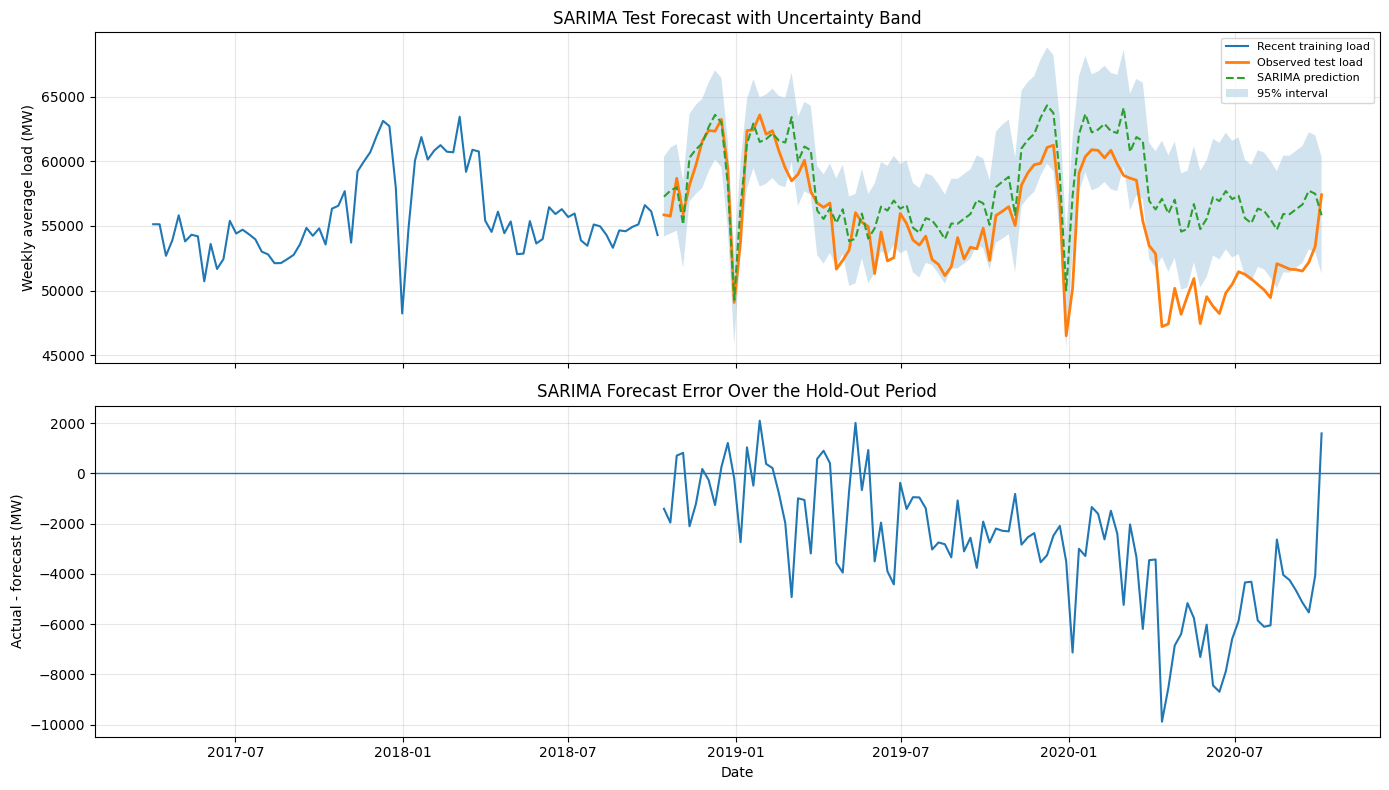

In [32]:
# This SARIMA figure shows both the forecast interval and the error path.
# I used this to check whether the model misses the level of the 2019-2020 test period.

sarima_error_v2 = test_v2 - sarima_forecast_v2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(train_v2.index[-80:], train_v2.iloc[-80:], label="Recent training load")
axes[0].plot(test_v2.index, test_v2, label="Observed test load", linewidth=2)
axes[0].plot(sarima_forecast_v2.index, sarima_forecast_v2, label="SARIMA prediction", linestyle="--")
axes[0].fill_between(
    test_v2.index,
    sarima_ci_v2.iloc[:, 0],
    sarima_ci_v2.iloc[:, 1],
    alpha=0.2,
    label="95% interval"
)
axes[0].set_title("SARIMA Test Forecast with Uncertainty Band")
axes[0].set_ylabel("Weekly average load (MW)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sarima_error_v2.index, sarima_error_v2)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("SARIMA Forecast Error Over the Hold-Out Period")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Actual - forecast (MW)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

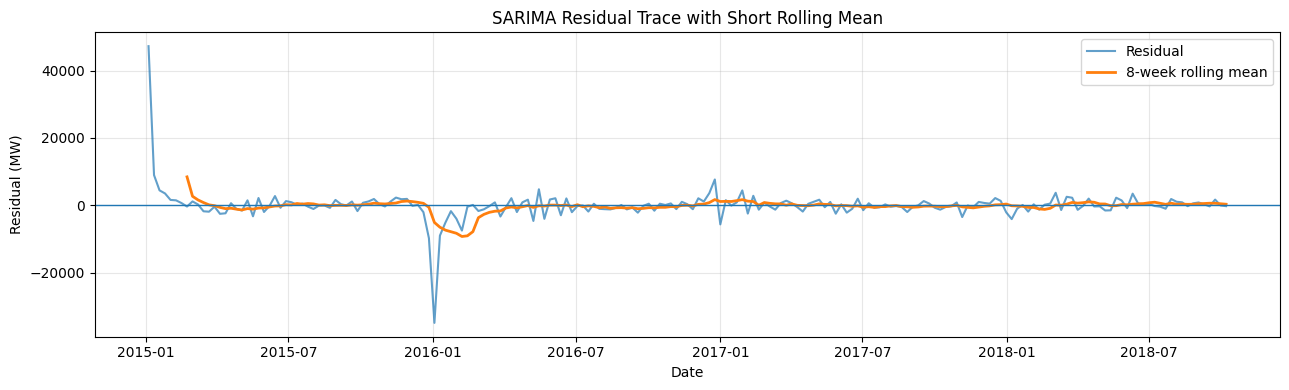

In [33]:
# Residuals should look like noise after a useful SARIMA fit.
# The rolling mean helps me see whether any slow bias is still left behind.

sarima_residuals_v2 = final_sarima_fit_v2.resid.dropna()
sarima_residual_roll_v2 = sarima_residuals_v2.rolling(window=8).mean()

plt.figure(figsize=(13, 4))
plt.plot(sarima_residuals_v2.index, sarima_residuals_v2.values, label="Residual", alpha=0.7)
plt.plot(sarima_residual_roll_v2.index, sarima_residual_roll_v2.values, label="8-week rolling mean", linewidth=2)
plt.axhline(0, linewidth=1)
plt.title("SARIMA Residual Trace with Short Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Residual (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

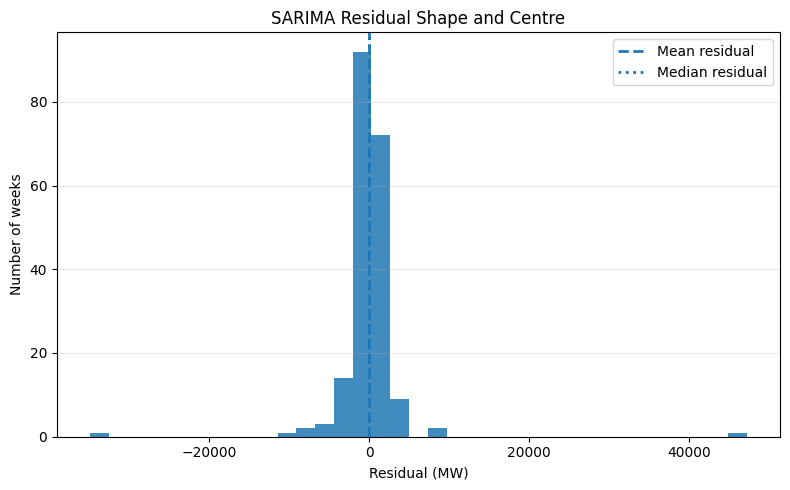

In [34]:
# This residual distribution check is mainly used to see whether errors are centred around zero.

plt.figure(figsize=(8, 5))
plt.hist(sarima_residuals_v2, bins=35, alpha=0.85)
plt.axvline(sarima_residuals_v2.mean(), linestyle="--", linewidth=2, label="Mean residual")
plt.axvline(sarima_residuals_v2.median(), linestyle=":", linewidth=2, label="Median residual")
plt.title("SARIMA Residual Shape and Centre")
plt.xlabel("Residual (MW)")
plt.ylabel("Number of weeks")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

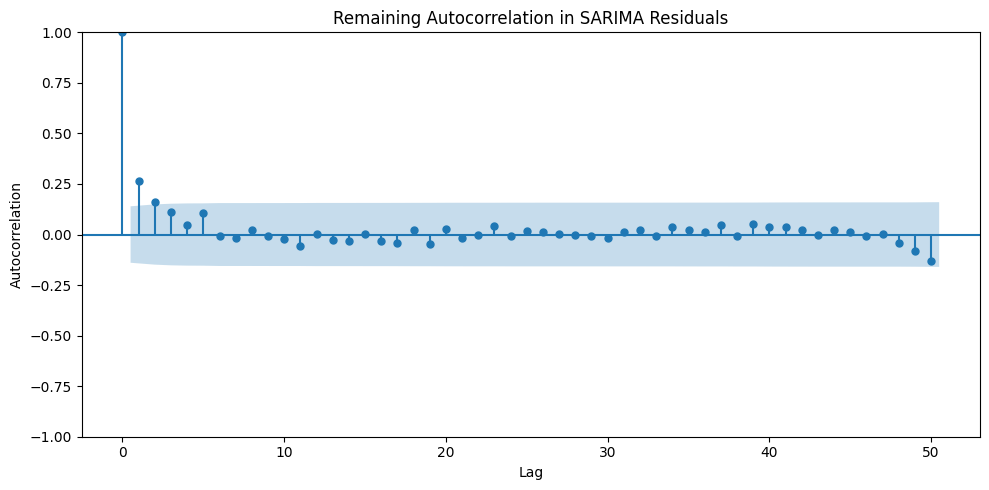

In [35]:
# If the residual ACF still has spikes, the model has not captured all dependence in the weekly data.

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(sarima_residuals_v2, lags=50, ax=ax)
ax.set_title("Remaining Autocorrelation in SARIMA Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

In [36]:
sarima_result_v2 = pd.DataFrame([
    {
        "Model": "SARIMA",
        "RMSE": sarima_rmse_v2,
        "MAE": sarima_mae_v2,
        "MAPE": sarima_mape_v2
    }
])

sarima_result_v2

,Model,RMSE,MAE,MAPE
0,SARIMA,3796.117303,3077.382741,5.840582


In [37]:
# SARIMAX model using Berlin temperature and lagged temperature

import requests
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [38]:
# Berlin coordinates
# Latitude: 52.52
# Longitude: 13.41

temperature_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=52.52&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=UTC"
)

response = requests.get(temperature_url)
temperature_json = response.json()

temperature_json.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [39]:
# Convert temperature data into dataframe

berlin_temp = pd.DataFrame({
    "date": temperature_json["daily"]["time"],
    "temperature": temperature_json["daily"]["temperature_2m_mean"]
})

berlin_temp["date"] = pd.to_datetime(berlin_temp["date"])
berlin_temp = berlin_temp.set_index("date")

berlin_temp.head()

,temperature
date,
2015-01-01,2.6
2015-01-02,4.9
2015-01-03,3.8
2015-01-04,2.8
2015-01-05,2.9


In [40]:
# Make timezone consistent with load data

berlin_temp.index = berlin_temp.index.tz_localize("UTC")

print(berlin_temp.head())
print(berlin_temp.tail())

                           temperature
date                                  
2015-01-01 00:00:00+00:00          2.6
2015-01-02 00:00:00+00:00          4.9
2015-01-03 00:00:00+00:00          3.8
2015-01-04 00:00:00+00:00          2.8
2015-01-05 00:00:00+00:00          2.9
                           temperature
date                                  
2020-09-26 00:00:00+00:00         10.5
2020-09-27 00:00:00+00:00          9.7
2020-09-28 00:00:00+00:00         12.7
2020-09-29 00:00:00+00:00         13.3
2020-09-30 00:00:00+00:00         12.9


In [41]:
# Weekly average temperature

weekly_temperature = berlin_temp["temperature"].resample("W").mean()

print("Weekly temperature observations:", len(weekly_temperature))
weekly_temperature.head()

Weekly temperature observations: 301


,temperature
date,
2015-01-04 00:00:00+00:00,3.525000
2015-01-11 00:00:00+00:00,3.914286
2015-01-18 00:00:00+00:00,4.842857
2015-01-25 00:00:00+00:00,0.057143
2015-02-01 00:00:00+00:00,1.400000


In [42]:
# Combine weekly electricity demand and weekly temperature

sarimax_table_v2 = pd.DataFrame({
    "load": weekly_demand_v2,
    "temperature": weekly_temperature
})

# Innovative feature: previous week's temperature
sarimax_table_v2["temperature_lag1"] = sarimax_table_v2["temperature"].shift(1)

sarimax_table_v2 = sarimax_table_v2.dropna()

print(sarimax_table_v2.head())
print(sarimax_table_v2.tail())
print(sarimax_table_v2.shape)

                                   load  temperature  temperature_lag1
2015-01-11 00:00:00+00:00  56191.101190     3.914286          3.525000
2015-01-18 00:00:00+00:00  57672.678571     4.842857          3.914286
2015-01-25 00:00:00+00:00  58613.303571     0.057143          4.842857
2015-02-01 00:00:00+00:00  58734.029762     1.400000          0.057143
2015-02-08 00:00:00+00:00  59323.898810    -1.228571          1.400000
                                   load  temperature  temperature_lag1
2020-09-06 00:00:00+00:00  51617.744048    15.942857         17.728571
2020-09-13 00:00:00+00:00  51507.630952    16.485714         15.942857
2020-09-20 00:00:00+00:00  52181.327381    17.214286         16.485714
2020-09-27 00:00:00+00:00  53411.934524    15.000000         17.214286
2020-10-04 00:00:00+00:00  57410.319444    12.966667         15.000000
(300, 3)


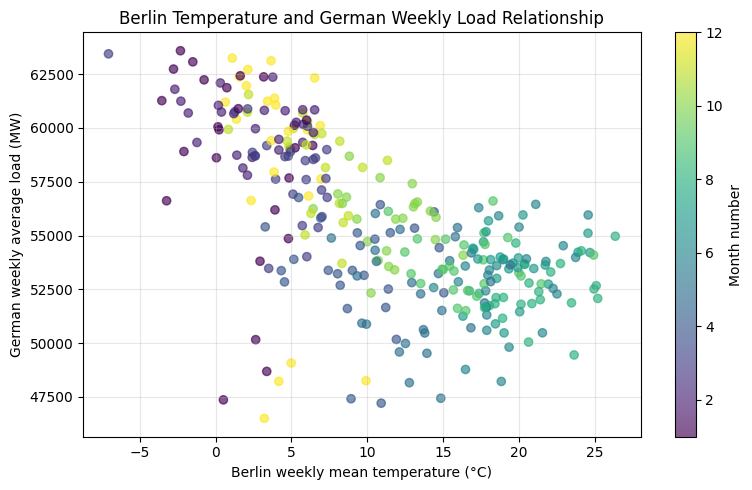

In [43]:
# Temperature is not the only driver of electricity demand, but this plot checks whether the relationship is visible.
# The points are coloured by month number so the seasonal pattern is not hidden.

plt.figure(figsize=(8, 5))
scatter_v2 = plt.scatter(
    sarimax_table_v2["temperature"],
    sarimax_table_v2["load"],
    c=sarimax_table_v2.index.month,
    alpha=0.65
)
plt.colorbar(scatter_v2, label="Month number")

plt.title("Berlin Temperature and German Weekly Load Relationship")
plt.xlabel("Berlin weekly mean temperature (°C)")
plt.ylabel("German weekly average load (MW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# Correlation check

correlation_table = sarimax_table_v2[
    ["load", "temperature", "temperature_lag1"]
].corr()

correlation_table

,load,temperature,temperature_lag1
load,1.000000,-0.651146,-0.626664
temperature,-0.651146,1.000000,0.915936
temperature_lag1,-0.626664,0.915936,1.000000


In [45]:
# Same final 104 weeks as the test period

sarimax_train_v2 = sarimax_table_v2.iloc[:-forecast_horizon]
sarimax_test_v2 = sarimax_table_v2.iloc[-forecast_horizon:]

y_train_sx_v2 = sarimax_train_v2["load"]
y_test_sx_v2 = sarimax_test_v2["load"]

x_train_sx_v2 = sarimax_train_v2[["temperature", "temperature_lag1"]]
x_test_sx_v2 = sarimax_test_v2[["temperature", "temperature_lag1"]]

print("SARIMAX train size:", len(y_train_sx_v2))
print("SARIMAX test size:", len(y_test_sx_v2))

SARIMAX train size: 196
SARIMAX test size: 104


In [46]:
# SARIMAX model with temperature variables

sarimax_model_v2 = SARIMAX(
    y_train_sx_v2,
    exog=x_train_sx_v2,
    order=final_sarima_order_v2,
    seasonal_order=seasonal_structure,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit_v2 = sarimax_model_v2.fit(disp=False)

print(sarimax_fit_v2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                 load   No. Observations:                  196
Model:             SARIMAX(0, 1, 6)x(1, 1, [1], 52)   Log Likelihood                -724.864
Date:                              Mon, 13 Jul 2026   AIC                           1471.728
Time:                                      07:26:37   BIC                           1498.467
Sample:                                  01-11-2015   HQIC                          1482.477
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
temperature        -88.5899     56.009     -1.582      0.114    -198.366      21.186
t

In [47]:
# Forecast using temperature variables from the test period

sarimax_forecast_object_v2 = sarimax_fit_v2.get_forecast(
    steps=len(y_test_sx_v2),
    exog=x_test_sx_v2
)

sarimax_forecast_v2 = sarimax_forecast_object_v2.predicted_mean
sarimax_forecast_v2.index = y_test_sx_v2.index

sarimax_confidence_v2 = sarimax_forecast_object_v2.conf_int()
sarimax_confidence_v2.index = y_test_sx_v2.index

In [48]:
sarimax_rmse_v2, sarimax_mae_v2, sarimax_mape_v2 = score_forecast(
    y_test_sx_v2,
    sarimax_forecast_v2
)

print("SARIMAX Results")
print("RMSE:", sarimax_rmse_v2)
print("MAE:", sarimax_mae_v2)
print("MAPE:", sarimax_mape_v2)

SARIMAX Results
RMSE: 4347.120743533896
MAE: 3515.289554341233
MAPE: 6.686430632760739


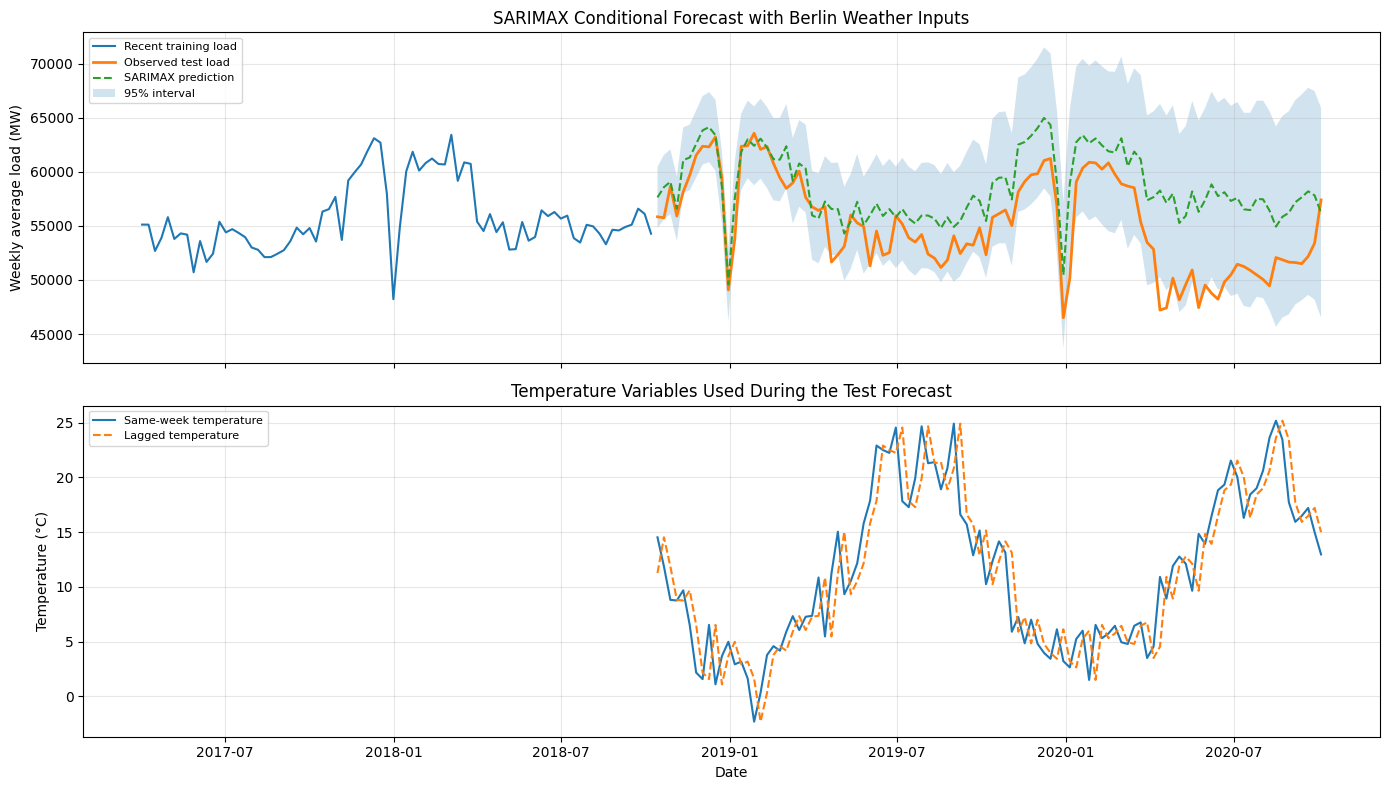

In [49]:
# This plot keeps the SARIMAX forecast and the weather inputs together.
# It makes clear that the temperature series is being used as an explanatory variable.

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_train_sx_v2.index[-80:], y_train_sx_v2.iloc[-80:], label="Recent training load")
axes[0].plot(y_test_sx_v2.index, y_test_sx_v2, label="Observed test load", linewidth=2)
axes[0].plot(sarimax_forecast_v2.index, sarimax_forecast_v2, label="SARIMAX prediction", linestyle="--")
axes[0].fill_between(
    y_test_sx_v2.index,
    sarimax_confidence_v2.iloc[:, 0],
    sarimax_confidence_v2.iloc[:, 1],
    alpha=0.2,
    label="95% interval"
)
axes[0].set_title("SARIMAX Conditional Forecast with Berlin Weather Inputs")
axes[0].set_ylabel("Weekly average load (MW)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_test_sx_v2.index, x_test_sx_v2["temperature"], label="Same-week temperature")
axes[1].plot(x_test_sx_v2.index, x_test_sx_v2["temperature_lag1"], label="Lagged temperature", linestyle="--")
axes[1].set_title("Temperature Variables Used During the Test Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Temperature (°C)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
sarimax_result_v2 = pd.DataFrame([
    {
        "Model": "SARIMAX",
        "RMSE": sarimax_rmse_v2,
        "MAE": sarimax_mae_v2,
        "MAPE": sarimax_mape_v2
    }
])

statistical_models_v2 = pd.concat(
    [sarima_result_v2, sarimax_result_v2],
    ignore_index=True
)

statistical_models_v2

,Model,RMSE,MAE,MAPE
0,SARIMA,3796.117303,3077.382741,5.840582
1,SARIMAX,4347.120744,3515.289554,6.686431


In [51]:
# Extract temperature-related coefficients

sarimax_params_v2 = sarimax_fit_v2.params

temperature_coefficients_v2 = sarimax_params_v2[
    sarimax_params_v2.index.str.contains("temperature")
]

temperature_coefficients_v2

,0
temperature,-88.589920
temperature_lag1,-101.057967


In [52]:
# Gradient Boosting regression model

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

In [53]:
# Taking from SARIMAX table

gb_data_v2 = sarimax_table_v2.copy()

gb_data_v2.head()

,load,temperature,temperature_lag1
2015-01-11 00:00:00+00:00,56191.101190,3.914286,3.525000
2015-01-18 00:00:00+00:00,57672.678571,4.842857,3.914286
2015-01-25 00:00:00+00:00,58613.303571,0.057143,4.842857
2015-02-01 00:00:00+00:00,58734.029762,1.400000,0.057143
2015-02-08 00:00:00+00:00,59323.898810,-1.228571,1.400000


In [54]:
# Lag features

gb_data_v2["load_lag_1"] = gb_data_v2["load"].shift(1)
gb_data_v2["load_lag_2"] = gb_data_v2["load"].shift(2)
gb_data_v2["load_lag_4"] = gb_data_v2["load"].shift(4)
gb_data_v2["load_lag_8"] = gb_data_v2["load"].shift(8)
gb_data_v2["load_lag_52"] = gb_data_v2["load"].shift(52)

In [55]:
# Rolling averages are shifted by 1 week to avoid using the current target value

gb_data_v2["rolling_mean_4"] = gb_data_v2["load"].shift(1).rolling(window=4).mean()
gb_data_v2["rolling_mean_12"] = gb_data_v2["load"].shift(1).rolling(window=12).mean()

# Recent weekly change
gb_data_v2["load_change_1"] = gb_data_v2["load"].shift(1) - gb_data_v2["load"].shift(2)

In [56]:
# Calendar features

gb_data_v2["week_number"] = gb_data_v2.index.isocalendar().week.astype(int)
gb_data_v2["month_number"] = gb_data_v2.index.month

# Cyclical transformation for seasonality

gb_data_v2["week_sin"] = np.sin(2 * np.pi * gb_data_v2["week_number"] / 52)
gb_data_v2["week_cos"] = np.cos(2 * np.pi * gb_data_v2["week_number"] / 52)

gb_data_v2["month_sin"] = np.sin(2 * np.pi * gb_data_v2["month_number"] / 12)
gb_data_v2["month_cos"] = np.cos(2 * np.pi * gb_data_v2["month_number"] / 12)

In [57]:
# Adding a few main German public holidays
# I am counting how many holidays fall inside each weekly row.

from dateutil.easter import easter

holiday_list_v2 = []

for y in range(2015, 2021):
    easter_date = pd.Timestamp(easter(y))

    holiday_list_v2.append(pd.Timestamp(f"{y}-01-01"))                 # New Year
    holiday_list_v2.append(easter_date - pd.Timedelta(days=2))         # Good Friday
    holiday_list_v2.append(easter_date + pd.Timedelta(days=1))         # Easter Monday
    holiday_list_v2.append(pd.Timestamp(f"{y}-05-01"))                 # Labour Day
    holiday_list_v2.append(easter_date + pd.Timedelta(days=39))        # Ascension Day
    holiday_list_v2.append(easter_date + pd.Timedelta(days=50))        # Whit Monday
    holiday_list_v2.append(pd.Timestamp(f"{y}-10-03"))                 # German Unity Day
    holiday_list_v2.append(pd.Timestamp(f"{y}-12-25"))                 # Christmas
    holiday_list_v2.append(pd.Timestamp(f"{y}-12-26"))                 # Second Christmas Day

holiday_list_v2 = pd.to_datetime(holiday_list_v2)

# Make the holiday dates match the timezone of the weekly data.
if gb_data_v2.index.tz is not None:
    holiday_list_v2 = holiday_list_v2.tz_localize("UTC")

holiday_counts_v2 = []

for week_date in gb_data_v2.index:
    start_date = week_date - pd.Timedelta(days=6)

    count = (
        (holiday_list_v2 >= start_date)
        & (holiday_list_v2 <= week_date)
    ).sum()

    holiday_counts_v2.append(count)

gb_data_v2["holiday_count"] = holiday_counts_v2
gb_data_v2["holiday_week"] = (gb_data_v2["holiday_count"] > 0).astype(int)

gb_data_v2[["holiday_count", "holiday_week"]].head()


,holiday_count,holiday_week
2015-01-11 00:00:00+00:00,0,0
2015-01-18 00:00:00+00:00,0,0
2015-01-25 00:00:00+00:00,0,0
2015-02-01 00:00:00+00:00,0,0
2015-02-08 00:00:00+00:00,0,0


In [58]:
# Remove rows with missing values caused by lagging and rolling windows

gb_data_v2 = gb_data_v2.dropna()

print(gb_data_v2.shape)
gb_data_v2.head()

(248, 19)


,load,temperature,temperature_lag1,load_lag_1,load_lag_2,load_lag_4,load_lag_8,load_lag_52,rolling_mean_4,rolling_mean_12,load_change_1,week_number,month_number,week_sin,week_cos,month_sin,month_cos,holiday_count,holiday_week
2016-01-10 00:00:00+00:00,56615.142857,-3.228571,0.514286,47364.035714,48253.363095,59907.333333,58491.214286,56191.101190,53288.147321,56330.935020,-889.327381,1,1,0.120537,0.992709,0.500000,0.866025,0,0
2016-01-17 00:00:00+00:00,59913.910714,0.228571,-3.228571,56615.142857,47364.035714,57627.857143,59382.172619,57672.678571,52465.099702,56361.866071,9251.107143,2,1,0.239316,0.970942,0.500000,0.866025,0,0
2016-01-24 00:00:00+00:00,61267.529762,-3.542857,0.228571,59913.910714,56615.142857,48253.363095,60732.666667,58613.303571,53036.613095,56707.694940,3298.767857,3,1,0.354605,0.935016,0.500000,0.866025,0,0
2016-01-31 00:00:00+00:00,59185.089286,6.400000,-3.542857,61267.529762,59913.910714,47364.035714,60106.678571,58734.029762,56290.154762,57179.856647,1353.619048,4,1,0.464723,0.885456,0.500000,0.866025,0,0
2016-02-07 00:00:00+00:00,59329.809524,5.742857,6.400000,59185.089286,61267.529762,56615.142857,59907.333333,59323.898810,59245.418155,57403.916171,-2082.440476,5,2,0.568065,0.822984,0.866025,0.500000,0,0


In [59]:
gb_features_v2 = [
    "temperature_lag1",
    "holiday_count",
    "holiday_week",
    "load_lag_1",
    "load_lag_2",
    "load_lag_4",
    "load_lag_8",
    "load_lag_52",
    "rolling_mean_4",
    "rolling_mean_12",
    "load_change_1",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos"
]

X_gb_v2 = gb_data_v2[gb_features_v2]
y_gb_v2 = gb_data_v2["load"]

print(X_gb_v2.head())
print(y_gb_v2.head())

                           temperature_lag1  holiday_count  holiday_week  \
2016-01-10 00:00:00+00:00          0.514286              0             0   
2016-01-17 00:00:00+00:00         -3.228571              0             0   
2016-01-24 00:00:00+00:00          0.228571              0             0   
2016-01-31 00:00:00+00:00         -3.542857              0             0   
2016-02-07 00:00:00+00:00          6.400000              0             0   

                             load_lag_1    load_lag_2    load_lag_4  \
2016-01-10 00:00:00+00:00  47364.035714  48253.363095  59907.333333   
2016-01-17 00:00:00+00:00  56615.142857  47364.035714  57627.857143   
2016-01-24 00:00:00+00:00  59913.910714  56615.142857  48253.363095   
2016-01-31 00:00:00+00:00  61267.529762  59913.910714  47364.035714   
2016-02-07 00:00:00+00:00  59185.089286  61267.529762  56615.142857   

                             load_lag_8   load_lag_52  rolling_mean_4  \
2016-01-10 00:00:00+00:00  58491.214286  56

In [60]:
# Keep final 104 weeks for testing

gb_train_size_v2 = len(gb_data_v2) - forecast_horizon

X_train_gb_v2 = X_gb_v2.iloc[:gb_train_size_v2]
X_test_gb_v2 = X_gb_v2.iloc[gb_train_size_v2:]

y_train_gb_v2 = y_gb_v2.iloc[:gb_train_size_v2]
y_test_gb_v2 = y_gb_v2.iloc[gb_train_size_v2:]

print("Training size:", X_train_gb_v2.shape)
print("Testing size:", X_test_gb_v2.shape)

Training size: (144, 15)
Testing size: (104, 15)


In [61]:
# Gradient Boosting model

gb_model_v2 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_model_v2.fit(X_train_gb_v2, y_train_gb_v2)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42,
                          subsample=0.8)

In [62]:
# Forecast test period

gb_forecast_v2 = gb_model_v2.predict(X_test_gb_v2)

gb_forecast_v2 = pd.Series(
    gb_forecast_v2,
    index=y_test_gb_v2.index,
    name="Gradient Boosting Forecast"
)

gb_forecast_v2.head()

,Gradient Boosting Forecast
2018-10-14 00:00:00+00:00,56423.744559
2018-10-21 00:00:00+00:00,57539.493607
2018-10-28 00:00:00+00:00,58500.511485
2018-11-04 00:00:00+00:00,55090.549392
2018-11-11 00:00:00+00:00,58774.539553


In [63]:
gb_rmse_v2, gb_mae_v2, gb_mape_v2 = score_forecast(
    y_test_gb_v2,
    gb_forecast_v2
)

print("Gradient Boosting Results")
print("RMSE:", gb_rmse_v2)
print("MAE:", gb_mae_v2)
print("MAPE:", gb_mape_v2)

Gradient Boosting Results
RMSE: 2397.84016718848
MAE: 1808.555896824748
MAPE: 3.446656257447949


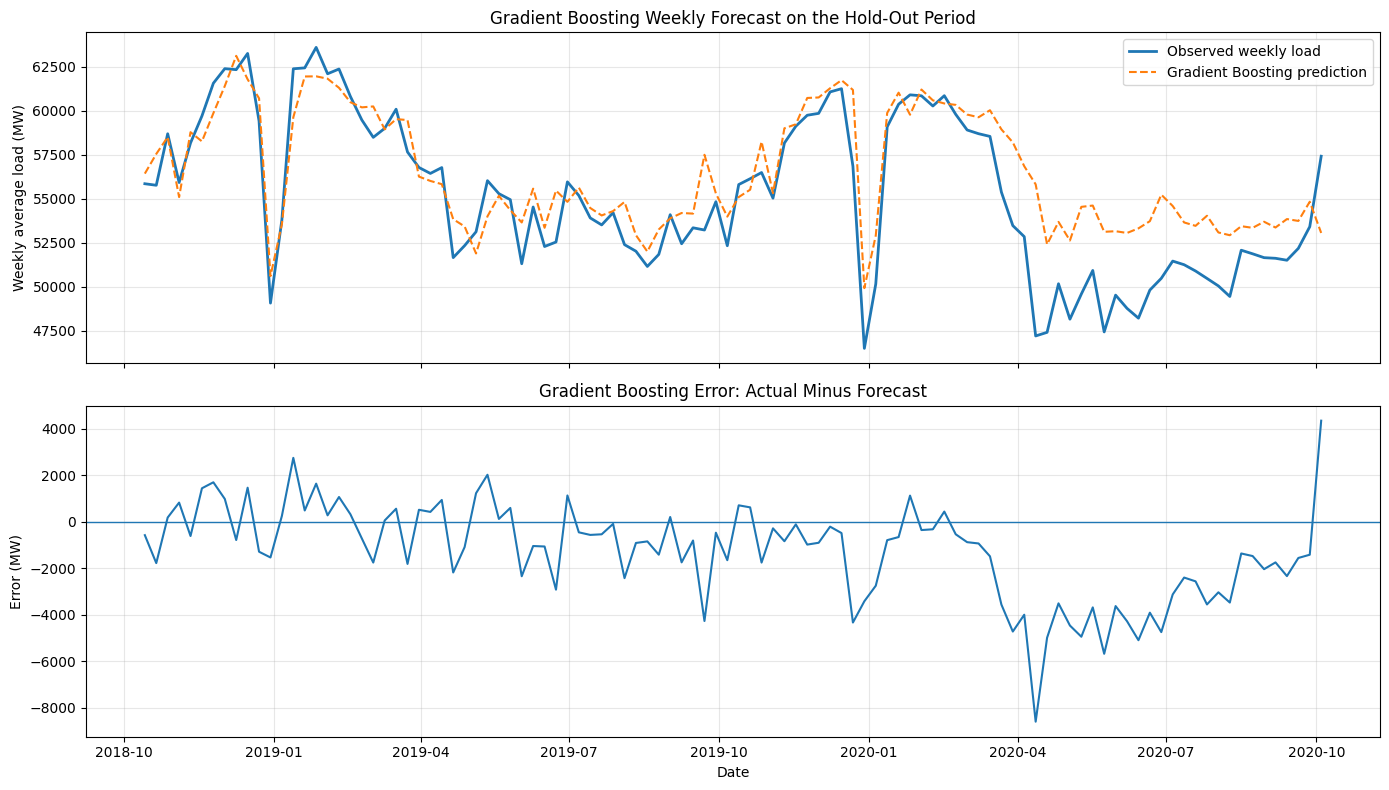

In [64]:
# Gradient Boosting is judged not only by the line fit but also by when the biggest errors happen.

gb_error_v2 = y_test_gb_v2 - gb_forecast_v2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_test_gb_v2.index, y_test_gb_v2, label="Observed weekly load", linewidth=2)
axes[0].plot(gb_forecast_v2.index, gb_forecast_v2, label="Gradient Boosting prediction", linestyle="--")
axes[0].set_title("Gradient Boosting Weekly Forecast on the Hold-Out Period")
axes[0].set_ylabel("Weekly average load (MW)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(gb_error_v2.index, gb_error_v2)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Gradient Boosting Error: Actual Minus Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Error (MW)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Feature importance table

gb_importance_v2 = pd.DataFrame({
    "Feature": gb_features_v2,
    "Importance": gb_model_v2.feature_importances_
})

gb_importance_v2 = gb_importance_v2.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

gb_importance_v2

,Feature,Importance
0,load_lag_52,0.717746
1,load_lag_1,0.079614
2,temperature_lag1,0.041150
3,week_cos,0.031661
4,load_lag_4,0.025493
5,holiday_count,0.017508
6,holiday_week,0.015457
7,rolling_mean_12,0.015325
8,rolling_mean_4,0.012923
9,load_lag_8,0.012432


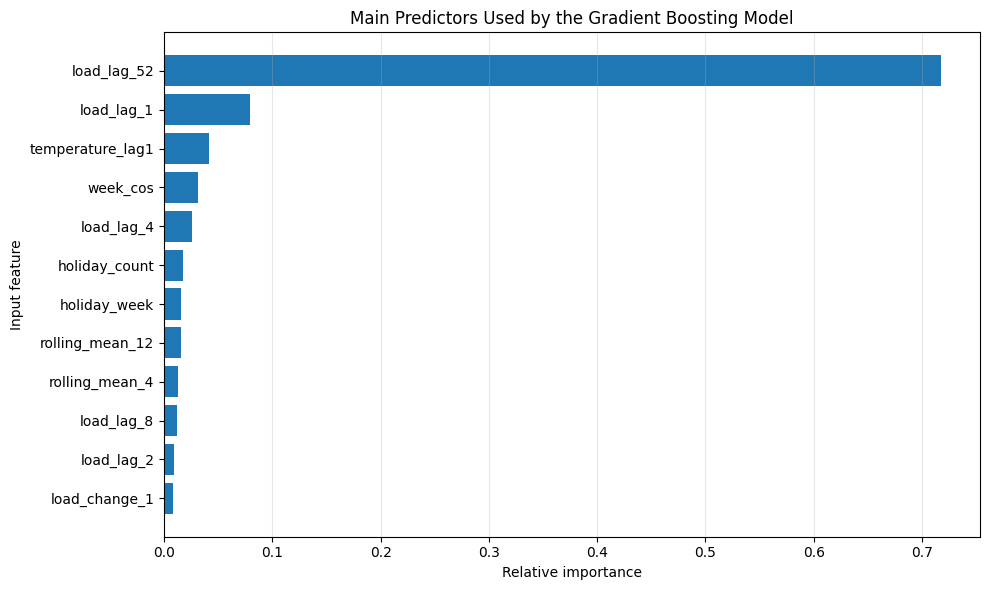

In [66]:
# Feature importance gives a simple way to explain what the regression model is relying on.
# I show the strongest features only, so the chart stays readable in the final report.

top_importance_v2 = gb_importance_v2.head(12).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    top_importance_v2["Feature"],
    top_importance_v2["Importance"]
)

plt.title("Main Predictors Used by the Gradient Boosting Model")
plt.xlabel("Relative importance")
plt.ylabel("Input feature")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
gb_result_v2 = pd.DataFrame([
    {
        "Model": "Gradient Boosting",
        "RMSE": gb_rmse_v2,
        "MAE": gb_mae_v2,
        "MAPE": gb_mape_v2
    }
])

models_until_gb_v2 = pd.concat(
    [
        benchmark_results_v2.head(1)[["Model", "RMSE", "MAE", "MAPE"]],
        sarima_result_v2,
        sarimax_result_v2,
        gb_result_v2
    ],
    ignore_index=True
)

models_until_gb_v2

,Model,RMSE,MAE,MAPE
0,Seasonal Naive Forecast,3006.760812,2318.520585,4.408920
1,SARIMA,3796.117303,3077.382741,5.840582
2,SARIMAX,4347.120744,3515.289554,6.686431
3,Gradient Boosting,2397.840167,1808.555897,3.446656


In [68]:
# Checking whether temperature and holiday features improve Gradient Boosting

base_features_v2 = [
    "load_lag_1",
    "load_lag_2",
    "load_lag_4",
    "load_lag_8",
    "load_lag_52",
    "rolling_mean_4",
    "rolling_mean_12",
    "load_change_1",
    "week_sin",
    "week_cos",
    "month_sin",
    "month_cos"
]

temp_features_v2 = base_features_v2 + [
    "temperature_lag1"
]

temp_holiday_features_v2 = temp_features_v2 + [
    "holiday_count",
    "holiday_week"
]

gb_feature_sets_v2 = {
    "Load + calendar": base_features_v2,
    "Load + calendar + lagged temperature": temp_features_v2,
    "Load + calendar + lagged temperature + holidays": temp_holiday_features_v2
}

gb_covariate_results_v2 = []

for feature_set_name, feature_columns in gb_feature_sets_v2.items():

    X_temp_v2 = gb_data_v2[feature_columns]
    y_temp_v2 = gb_data_v2["load"]

    X_train_temp_v2 = X_temp_v2.iloc[:gb_train_size_v2]
    X_test_temp_v2 = X_temp_v2.iloc[gb_train_size_v2:]

    y_train_temp_v2 = y_temp_v2.iloc[:gb_train_size_v2]
    y_test_temp_v2 = y_temp_v2.iloc[gb_train_size_v2:]

    temp_gb_model_v2 = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )

    temp_gb_model_v2.fit(X_train_temp_v2, y_train_temp_v2)

    temp_forecast_v2 = temp_gb_model_v2.predict(X_test_temp_v2)

    temp_rmse_v2, temp_mae_v2, temp_mape_v2 = score_forecast(
        y_test_temp_v2,
        temp_forecast_v2
    )

    gb_covariate_results_v2.append({
        "Feature set": feature_set_name,
        "RMSE": temp_rmse_v2,
        "MAE": temp_mae_v2,
        "MAPE": temp_mape_v2
    })

gb_covariate_results_v2 = pd.DataFrame(gb_covariate_results_v2)
gb_covariate_results_v2


,Feature set,RMSE,MAE,MAPE
0,Load + calendar,2519.030984,1900.006023,3.623431
1,Load + calendar + lagged temperature,2566.407752,1911.150226,3.654739
2,Load + calendar + lagged temperature + holidays,2384.549256,1774.575130,3.379826


In [69]:
# LSTM model using hourly data with 336-hour lookback
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [70]:
# Use hourly German electricity demand from Part 1

hourly_lstm_v2 = germany[["load"]].copy()

print(hourly_lstm_v2.head())
print(hourly_lstm_v2.tail())
print(hourly_lstm_v2.shape)

                              load
timestamp                         
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                              load
timestamp                         
2020-09-30 19:00:00+00:00  57559.0
2020-09-30 20:00:00+00:00  54108.0
2020-09-30 21:00:00+00:00  49845.0
2020-09-30 22:00:00+00:00  46886.0
2020-09-30 23:00:00+00:00  45461.0
(50400, 1)


In [71]:
# Last 2 years of hourly data for testing

test_hours_v2 = 24 * 365 * 2

hourly_train_v2 = hourly_lstm_v2.iloc[:-test_hours_v2]
hourly_test_v2 = hourly_lstm_v2.iloc[-test_hours_v2:]

print("Training shape:", hourly_train_v2.shape)
print("Testing shape:", hourly_test_v2.shape)

print("Training period:", hourly_train_v2.index.min(), "to", hourly_train_v2.index.max())
print("Testing period:", hourly_test_v2.index.min(), "to", hourly_test_v2.index.max())

Training shape: (32880, 1)
Testing shape: (17520, 1)
Training period: 2015-01-01 00:00:00+00:00 to 2018-10-01 23:00:00+00:00
Testing period: 2018-10-02 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


In [72]:
# Scaling the data
# Important: scaler is fitted only on training data

scaler_v2 = MinMaxScaler()

scaled_train_v2 = scaler_v2.fit_transform(hourly_train_v2)
scaled_test_v2 = scaler_v2.transform(hourly_test_v2)

print(scaled_train_v2.shape)
print(scaled_test_v2.shape)

(32880, 1)
(17520, 1)


In [73]:
# Function to create sequences

def make_lstm_sequences(data, lookback):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    return X, y

In [78]:
# Small LSTM tuning check
# This is not a full deep learning search, but it compares different lookback and layer choices

lstm_tuning_results_v2 = []

lstm_tuning_setups_v2 = [
    {"Model": "LSTM 168h, 1 layer", "lookback": 168, "units_1": 50, "units_2": None},
    {"Model": "LSTM 336h, 1 layer", "lookback": 336, "units_1": 64, "units_2": None},
    {"Model": "LSTM 336h, 2 layers", "lookback": 336, "units_1": 64, "units_2": 32}
]

for setup_v2 in lstm_tuning_setups_v2:

    X_temp_v2, y_temp_v2 = make_lstm_sequences(
        scaled_train_v2,
        setup_v2["lookback"]
    )

    split_point_v2 = int(len(X_temp_v2) * 0.9)

    X_train_temp_v2 = X_temp_v2[:split_point_v2]
    X_val_temp_v2 = X_temp_v2[split_point_v2:]

    y_train_temp_v2 = y_temp_v2[:split_point_v2]
    y_val_temp_v2 = y_temp_v2[split_point_v2:]

    temp_lstm_v2 = Sequential()

    if setup_v2["units_2"] is None:
        temp_lstm_v2.add(
            LSTM(
                setup_v2["units_1"],
                input_shape=(X_train_temp_v2.shape[1], 1)
            )
        )
    else:
        temp_lstm_v2.add(
            LSTM(
                setup_v2["units_1"],
                return_sequences=True,
                input_shape=(X_train_temp_v2.shape[1], 1)
            )
        )
        temp_lstm_v2.add(Dropout(0.20))
        temp_lstm_v2.add(
            LSTM(setup_v2["units_2"])
        )

    temp_lstm_v2.add(Dropout(0.20))
    temp_lstm_v2.add(Dense(1))

    temp_lstm_v2.compile(
        optimizer="adam",
        loss="mse"
    )

    temp_lstm_v2.fit(
        X_train_temp_v2,
        y_train_temp_v2,
        epochs=5,
        batch_size=64,
        validation_data=(X_val_temp_v2, y_val_temp_v2),
        verbose=1
    )

    val_prediction_v2 = temp_lstm_v2.predict(
        X_val_temp_v2,
        verbose=0
    )

    val_rmse_v2 = np.sqrt(
        mean_squared_error(y_val_temp_v2, val_prediction_v2)
    )

    lstm_tuning_results_v2.append({
        "Model": setup_v2["Model"],
        "Lookback hours": setup_v2["lookback"],
        "Validation RMSE (scaled)": val_rmse_v2
    })

lstm_tuning_results_v2 = pd.DataFrame(lstm_tuning_results_v2)
lstm_tuning_results_v2

Epoch 1/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - loss: 0.0341 - val_loss: 0.0063
Epoch 2/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - loss: 0.0074 - val_loss: 0.0023
Epoch 3/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 34s 74ms/step - loss: 0.0046 - val_loss: 0.0016
Epoch 4/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - loss: 0.0037 - val_loss: 0.0010
Epoch 5/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - loss: 0.0030 - val_loss: 9.8643e-04
Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 92s 196ms/step - loss: 0.0206 - val_loss: 0.0044
Epoch 2/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 86s 189ms/step - loss: 0.0054 - val_loss: 0.0018
Epoch 3/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 89s 194ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 4/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 143s 197ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 5/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 139s 190ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 1/5
458/458 ━━━━━━━━━━━━━━━━━━━━ 188s 403ms/step - loss: 0.0199 - val_loss: 0.0039
Epoch 2/5
458/458 ━━━━━━━━━━━━

,Model,Lookback hours,Validation RMSE (scaled)
0,"LSTM 168h, 1 layer",168,0.031408
1,"LSTM 336h, 1 layer",336,0.032964
2,"LSTM 336h, 2 layers",336,0.030922


In [79]:
# Two-week lookback
# 24 hours * 14 days = 336 hours

lookback_v2 = 336

X_train_lstm_v2, y_train_lstm_v2 = make_lstm_sequences(
    scaled_train_v2,
    lookback_v2
)


test_sequence_input_v2 = np.vstack([
    scaled_train_v2[-lookback_v2:],
    scaled_test_v2
])

X_test_lstm_v2, y_test_lstm_v2 = make_lstm_sequences(
    test_sequence_input_v2,
    lookback_v2
)

print("X train:", X_train_lstm_v2.shape)
print("y train:", y_train_lstm_v2.shape)
print("X test:", X_test_lstm_v2.shape)
print("y test:", y_test_lstm_v2.shape)

X train: (32544, 336, 1)
y train: (32544,)
X test: (17520, 336, 1)
y test: (17520,)


In [80]:
# LSTM architecture for Version 2

lstm_model_v2 = Sequential()

lstm_model_v2.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train_lstm_v2.shape[1], 1)
    )
)

lstm_model_v2.add(Dropout(0.25))

lstm_model_v2.add(
    LSTM(
        units=32,
        return_sequences=False
    )
)

lstm_model_v2.add(Dropout(0.20))

lstm_model_v2.add(Dense(16, activation="relu"))
lstm_model_v2.add(Dense(1))

lstm_model_v2.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model_v2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 336, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 336, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Early stopping avoids unnecessary training if validation loss stops improving

early_stop_v2 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_v2 = lstm_model_v2.fit(
    X_train_lstm_v2,
    y_train_lstm_v2,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_v2],
    verbose=1
)

Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 187s 398ms/step - loss: 0.0237 - val_loss: 0.0045
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 187s 409ms/step - loss: 0.0054 - val_loss: 0.0035
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 191s 416ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 200s 411ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 197s 401ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 204s 406ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 7/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 209s 422ms/step - loss: 0.0017 - val_loss: 9.9259e-04
Epoch 8/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 183s 400ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 9/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 208s 413ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 10/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 203s 416ms/step - loss: 0.0013 - val_loss: 0.0019


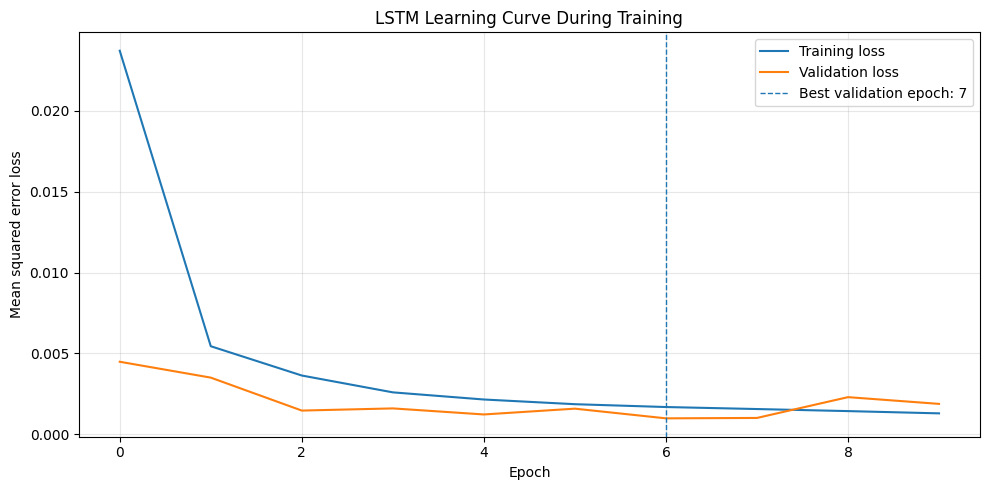

In [82]:
# The loss curve is used to check whether the LSTM is still learning or starting to overfit.

best_epoch_v2 = int(np.argmin(history_v2.history["val_loss"])) + 1

plt.figure(figsize=(10, 5))
plt.plot(history_v2.history["loss"], label="Training loss")
plt.plot(history_v2.history["val_loss"], label="Validation loss")
plt.axvline(best_epoch_v2 - 1, linestyle="--", linewidth=1, label=f"Best validation epoch: {best_epoch_v2}")

plt.title("LSTM Learning Curve During Training")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
# Generate predictions

lstm_scaled_predictions_v2 = lstm_model_v2.predict(X_test_lstm_v2)

# Convert scaled values back to MW

lstm_predictions_v2 = scaler_v2.inverse_transform(lstm_scaled_predictions_v2)
actual_lstm_values_v2 = scaler_v2.inverse_transform(
    y_test_lstm_v2.reshape(-1, 1)
)

lstm_predictions_v2 = lstm_predictions_v2.flatten()
actual_lstm_values_v2 = actual_lstm_values_v2.flatten()

print(lstm_predictions_v2[:5])
print(actual_lstm_values_v2[:5])

548/548 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step
[45208.316 45394.75  47412.812 52226.758 59180.367]
[44899. 45550. 47150. 51794. 59531.]


In [84]:
lstm_rmse_v2 = np.sqrt(
    mean_squared_error(actual_lstm_values_v2, lstm_predictions_v2)
)

lstm_mae_v2 = mean_absolute_error(
    actual_lstm_values_v2,
    lstm_predictions_v2
)

lstm_mape_v2 = np.mean(
    np.abs((actual_lstm_values_v2 - lstm_predictions_v2) / actual_lstm_values_v2)
) * 100

print("LSTM Results")
print("RMSE:", lstm_rmse_v2)
print("MAE:", lstm_mae_v2)
print("MAPE:", lstm_mape_v2)

LSTM Results
RMSE: 1642.2666551697882
MAE: 1271.5238889929367
MAPE: 2.2840894512321053


In [85]:
# Match predictions with test timestamps

lstm_forecast_index_v2 = hourly_test_v2.index

lstm_forecast_series_v2 = pd.Series(
    lstm_predictions_v2,
    index=lstm_forecast_index_v2,
    name="LSTM Forecast"
)

lstm_actual_series_v2 = pd.Series(
    actual_lstm_values_v2,
    index=lstm_forecast_index_v2,
    name="Actual Load"
)

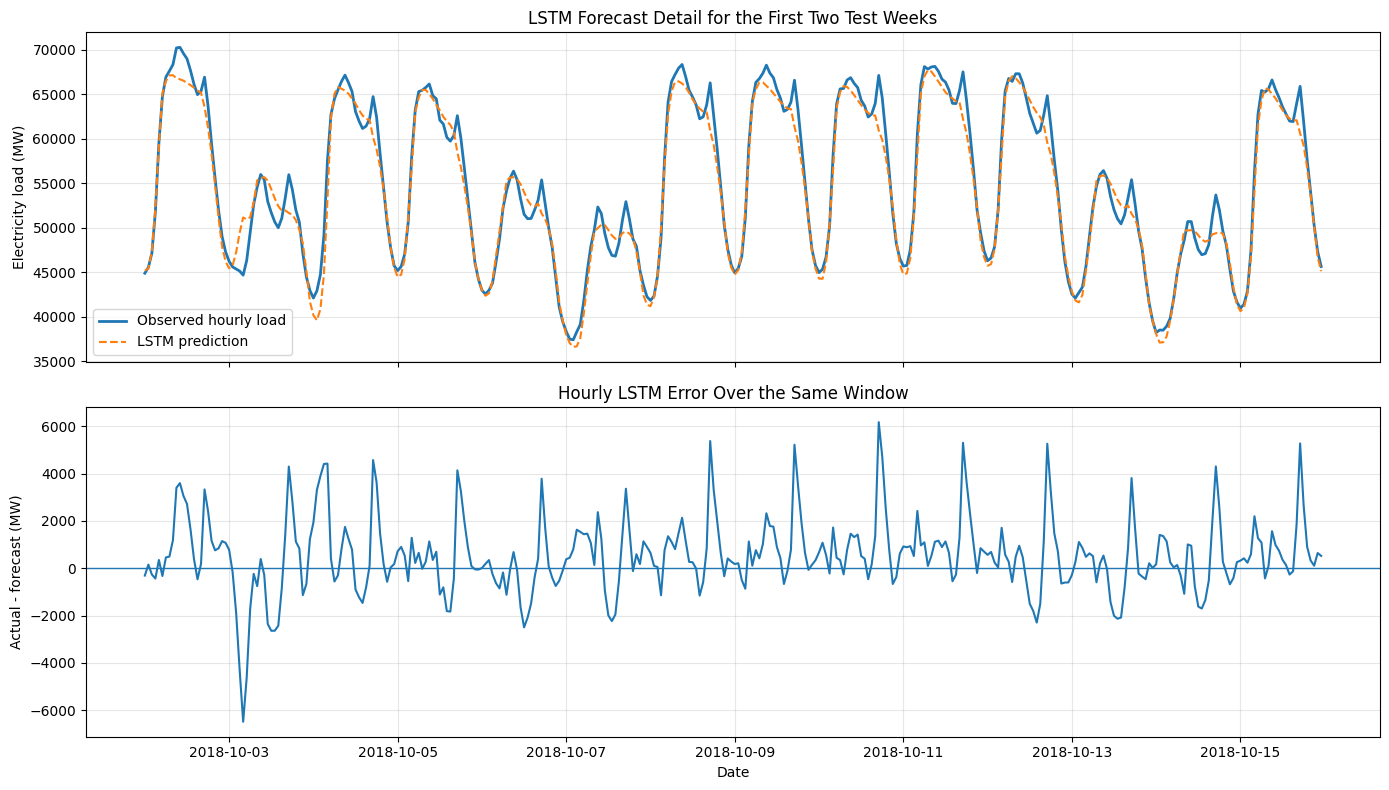

In [86]:
# I only plot the first two test weeks here so the hourly forecast can be inspected clearly.
# A longer plot becomes too compressed and hides the daily shape.

plot_hours_v2 = 24 * 14
lstm_hourly_error_v2 = lstm_actual_series_v2 - lstm_forecast_series_v2

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(lstm_actual_series_v2.iloc[:plot_hours_v2], label="Observed hourly load", linewidth=2)
axes[0].plot(lstm_forecast_series_v2.iloc[:plot_hours_v2], label="LSTM prediction", linestyle="--")
axes[0].set_title("LSTM Forecast Detail for the First Two Test Weeks")
axes[0].set_ylabel("Electricity load (MW)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_hourly_error_v2.iloc[:plot_hours_v2])
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Hourly LSTM Error Over the Same Window")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Actual - forecast (MW)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [87]:
lstm_result_v2 = pd.DataFrame([
    {
        "Model": "LSTM",
        "RMSE": lstm_rmse_v2,
        "MAE": lstm_mae_v2,
        "MAPE": lstm_mape_v2
    }
])

lstm_result_v2

,Model,RMSE,MAE,MAPE
0,LSTM,1642.266655,1271.523889,2.284089


In [88]:
# Weekly aggregation of hourly LSTM forecast
# This makes the LSTM result more comparable with the weekly models

lstm_weekly_table_v2 = pd.DataFrame({
    "actual": actual_lstm_values_v2,
    "forecast": lstm_predictions_v2
}, index=lstm_forecast_index_v2)

lstm_weekly_table_v2 = lstm_weekly_table_v2.resample("W").mean().dropna()

lstm_weekly_rmse_v2 = np.sqrt(
    mean_squared_error(
        lstm_weekly_table_v2["actual"],
        lstm_weekly_table_v2["forecast"]
    )
)

lstm_weekly_mae_v2 = mean_absolute_error(
    lstm_weekly_table_v2["actual"],
    lstm_weekly_table_v2["forecast"]
)

lstm_weekly_mape_v2 = np.mean(
    np.abs(
        (lstm_weekly_table_v2["actual"] - lstm_weekly_table_v2["forecast"])
        / lstm_weekly_table_v2["actual"]
    )
) * 100

lstm_weekly_result_v2 = pd.DataFrame([
    {
        "Model": "LSTM Weekly Aggregated",
        "RMSE": lstm_weekly_rmse_v2,
        "MAE": lstm_weekly_mae_v2,
        "MAPE": lstm_weekly_mape_v2
    }
])

lstm_weekly_result_v2


,Model,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,693.17942,610.14272,1.069861


In [89]:
# Combine all model results

# Best benchmark only
best_benchmark_result_v2 = benchmark_results_v2.head(1).copy()
best_benchmark_result_v2["Model"] = best_benchmark_result_v2["Model"] + " (Benchmark)"

# Add frequency column
best_benchmark_result_v2["Frequency"] = "Weekly"
sarima_result_v2["Frequency"] = "Weekly"
sarimax_result_v2["Frequency"] = "Weekly"
gb_result_v2["Frequency"] = "Weekly"
lstm_result_v2["Frequency"] = "Hourly"
lstm_weekly_result_v2["Frequency"] = "Weekly"

final_results_v2 = pd.concat(
    [
        best_benchmark_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]],
        sarima_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]],
        sarimax_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]],
        gb_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]],
        lstm_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]],
        lstm_weekly_result_v2[["Model", "Frequency", "RMSE", "MAE", "MAPE"]]
    ],
    ignore_index=True
)

final_results_v2 = final_results_v2.sort_values("RMSE").reset_index(drop=True)

final_results_v2

,Model,Frequency,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,Weekly,693.179420,610.142720,1.069861
1,LSTM,Hourly,1642.266655,1271.523889,2.284089
2,Gradient Boosting,Weekly,2397.840167,1808.555897,3.446656
3,Seasonal Naive Forecast (Benchmark),Weekly,3006.760812,2318.520585,4.408920
4,SARIMA,Weekly,3796.117303,3077.382741,5.840582
5,SARIMAX,Weekly,4347.120744,3515.289554,6.686431


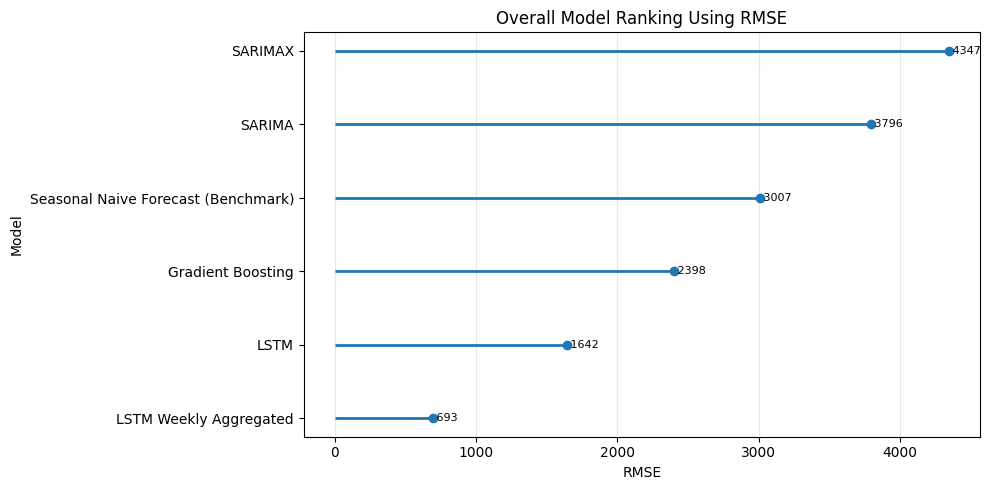

In [90]:
# Final RMSE ranking across all models.

ranked_rmse_v2 = final_results_v2.sort_values("RMSE", ascending=True).reset_index(drop=True)
y_positions_v2 = np.arange(len(ranked_rmse_v2))

plt.figure(figsize=(10, 5))
plt.hlines(y_positions_v2, 0, ranked_rmse_v2["RMSE"], linewidth=2)
plt.plot(ranked_rmse_v2["RMSE"], y_positions_v2, "o")

for y, value in zip(y_positions_v2, ranked_rmse_v2["RMSE"]):
    plt.text(value, y, f" {value:.0f}", va="center", fontsize=8)

plt.yticks(y_positions_v2, ranked_rmse_v2["Model"])
plt.title("Overall Model Ranking Using RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
weekly_only_results_v2 = final_results_v2[
    final_results_v2["Frequency"] == "Weekly"
].copy()

weekly_only_results_v2

,Model,Frequency,RMSE,MAE,MAPE
0,LSTM Weekly Aggregated,Weekly,693.179420,610.142720,1.069861
2,Gradient Boosting,Weekly,2397.840167,1808.555897,3.446656
3,Seasonal Naive Forecast (Benchmark),Weekly,3006.760812,2318.520585,4.408920
4,SARIMA,Weekly,3796.117303,3077.382741,5.840582
5,SARIMAX,Weekly,4347.120744,3515.289554,6.686431


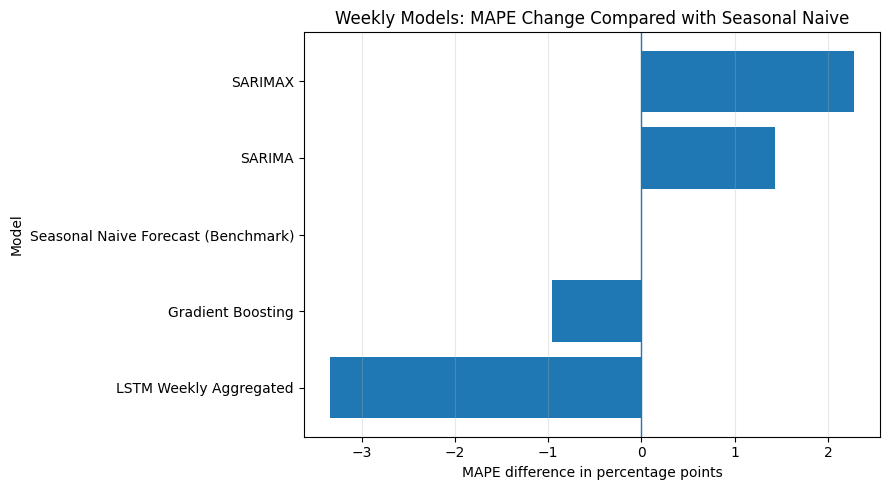

In [92]:
# This chart compares weekly MAPE values against the seasonal naive benchmark.
# Negative values mean the model improved on the benchmark; positive values mean it performed worse.

weekly_only_results_v2 = weekly_only_results_v2.copy()
benchmark_mape_v2 = weekly_only_results_v2.loc[
    weekly_only_results_v2["Model"].str.contains("Seasonal Naive", case=False),
    "MAPE"
].iloc[0]
weekly_only_results_v2["MAPE difference vs seasonal naive"] = weekly_only_results_v2["MAPE"] - benchmark_mape_v2

ordered_weekly_mape_v2 = weekly_only_results_v2.sort_values("MAPE difference vs seasonal naive")

plt.figure(figsize=(9, 5))
plt.barh(
    ordered_weekly_mape_v2["Model"],
    ordered_weekly_mape_v2["MAPE difference vs seasonal naive"]
)
plt.axvline(0, linewidth=1)
plt.title("Weekly Models: MAPE Change Compared with Seasonal Naive")
plt.xlabel("MAPE difference in percentage points")
plt.ylabel("Model")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

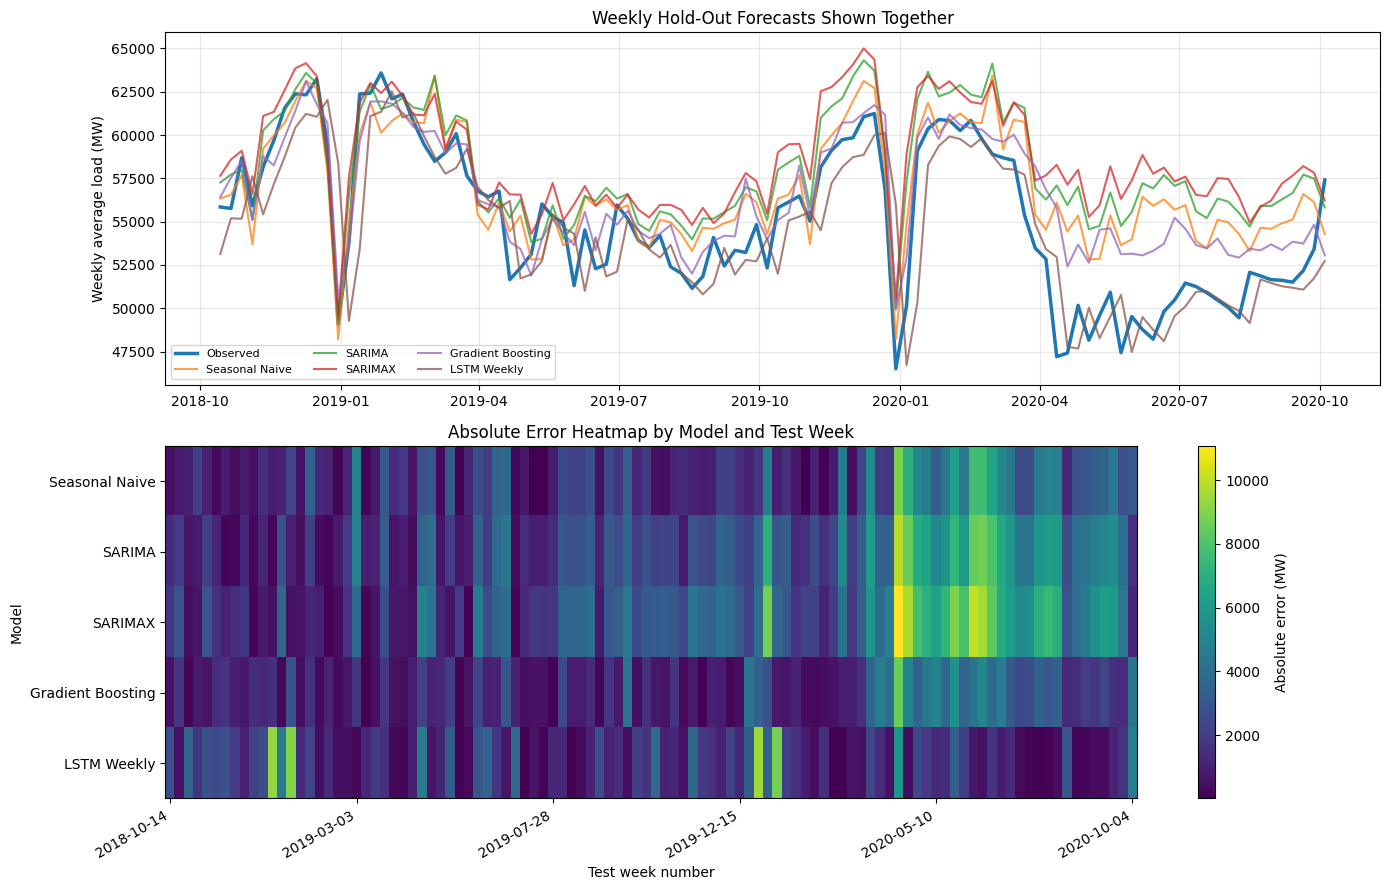

In [93]:
# Final weekly comparison: forecast lines + absolute error heatmap

final_weekly_forecasts_v2 = pd.DataFrame(index=test_v2.index)

final_weekly_forecasts_v2["Actual"] = test_v2.values
final_weekly_forecasts_v2["Seasonal Naive"] = benchmark_forecasts["Seasonal Naive Forecast"].values
final_weekly_forecasts_v2["SARIMA"] = sarima_forecast_v2.values
final_weekly_forecasts_v2["SARIMAX"] = sarimax_forecast_v2.reindex(test_v2.index).values
final_weekly_forecasts_v2["Gradient Boosting"] = gb_forecast_v2.reindex(test_v2.index).values

# LSTM weekly forecast is aligned by position because its weekly resample index can be slightly different
lstm_weekly_aligned_v2 = lstm_weekly_table_v2["forecast"].iloc[:len(test_v2)].values
final_weekly_forecasts_v2["LSTM Weekly"] = lstm_weekly_aligned_v2

model_names_v2 = [
    "Seasonal Naive",
    "SARIMA",
    "SARIMAX",
    "Gradient Boosting",
    "LSTM Weekly"
]

absolute_error_table_v2 = pd.DataFrame(index=final_weekly_forecasts_v2.index)

for model_name in model_names_v2:
    absolute_error_table_v2[model_name] = (
        final_weekly_forecasts_v2["Actual"] - final_weekly_forecasts_v2[model_name]
    ).abs()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# Top panel: forecast lines
axes[0].plot(
    final_weekly_forecasts_v2.index,
    final_weekly_forecasts_v2["Actual"],
    label="Observed",
    linewidth=2.5
)

for model_name in model_names_v2:
    axes[0].plot(
        final_weekly_forecasts_v2.index,
        final_weekly_forecasts_v2[model_name],
        label=model_name,
        alpha=0.75
    )

axes[0].set_title("Weekly Hold-Out Forecasts Shown Together")
axes[0].set_ylabel("Weekly average load (MW)")
axes[0].legend(ncol=3, fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bottom panel: heatmap
error_matrix_v2 = absolute_error_table_v2.T.values

image_v2 = axes[1].imshow(
    error_matrix_v2,
    aspect="auto"
)

axes[1].set_title("Absolute Error Heatmap by Model and Test Week")
axes[1].set_ylabel("Model")
axes[1].set_yticks(np.arange(len(model_names_v2)))
axes[1].set_yticklabels(model_names_v2)
axes[1].set_xlabel("Test week number")

# Put a few week labels instead of overcrowding the axis
tick_positions_v2 = np.linspace(0, len(test_v2) - 1, 6, dtype=int)
tick_labels_v2 = [test_v2.index[i].strftime("%Y-%m-%d") for i in tick_positions_v2]

axes[1].set_xticks(tick_positions_v2)
axes[1].set_xticklabels(tick_labels_v2, rotation=30, ha="right")

fig.colorbar(image_v2, ax=axes[1], label="Absolute error (MW)")

plt.tight_layout()
plt.show()